# Purpose: Find out why some mutants are different than others.

In [1]:
from scipy.io import loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from mapd import Trial, Table, Sinq 
from mapd.sinq_builders import build_composite_sinq, subset_sinq
import h5py
import glob
import numpy as np
import pickle
import plotly.express as px
import matplotlib.colors as mcolors
# import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 11

import seaborn as sns

import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import mannwhitneyu

from IPython.display import display

%load_ext autoreload
%autoreload 2


%matplotlib widget

def refresh_table_addons():
    import importlib
    import mapd.table_plotters as tps
    import mapd.table_scalars as tbs
    importlib.reload(tps)
    importlib.reload(tbs)

    for name in dir(tps):
        if name.startswith('_'):
            continue
        attr = getattr(tps, name)
        setattr(Table, name[len("plot_"):], attr)
    
    for name in dir(tbs):
        if name.startswith('_'):
            continue
        if name.startswith('compute_'):
            attr = getattr(tbs, name)
            setattr(Table, name[len("compute_"):], attr)


# Fig dir for PCA analysis
mutant_fig_dir = 'Figure5_mutant_plots'

os.makedirs(mutant_fig_dir, exist_ok=True)

# Load learners vs. control sinq

In [2]:
sinq_1_2 = Sinq(sinqname='dataset_1_2_pca_lda') # Constructed in Figure4_Fig5 code
sinq_1 =  Sinq(sinqname='dataset_1') 

Found data directory: D:\Data
Found data directory: D:\Data


# Import mutant sinq and select other rows

In [3]:
sinq_g = Sinq(sinqname='dataset_3_genetic_manipulations')
print(sinq_g.__repr__())

Found data directory: D:\Data
Sinq(dataset_3_genetic_manipulations, 36 rows x 33 params): 0 empties; ['241205_F2_C1', '241205_F3_C1', '241219_F1_C1', '241219_F2_C1', '241220_F1_C1', '241220_F2_C1', '250127_F1_C1', '250127_F2_C1', '250128_F1_C1', '250204_F1_C1', '250204_F2_C1', '250211_F2_C1', '250211_F3_C1', '250317_F1_C1', '250317_F2_C1', '250318_F1_C1', '250318_F2_C1', '250318_F3_C1', '250320_F1_C1', '250320_F2_C1', '250325_F1_C1', '250423_F1_C1', '250423_F2_C1', '250506_F1_C1', '250507_F1_C1', '250507_F2_C1', '250509_F2_C1', '250514_F1_C1', '250515_F1_C1', '251114_F1_C2', '251217_F2_C1', '260527_F1_C1', '260527_F4_C1', '260605_F1_C1', '260605_F2_C1', '260605_F3_C1'] x ['Table', 'parquet', 'genotype', 'notes', 'duration', 'rms_velocity', 'outcome_fractions_no_as_no_mv', 'outcome_fractions_as_off', 'outcome_fractions_rest', 'outcome_fractions_no_as_mv', 'outcome_fractions_probe', 'outcome_fractions_as_off_late', 'outcome_fractions_timeout_fail', 'outcome_fractions_timeout', 'outcome_f

# Per-state probe position across trials
Test of new `Table.plot_state_positions` — shows where the probe sits during REST, DRIFT, and MOVE samples on each trial, with target bands for context. Useful for asking whether some flies hold the probe beyond the target zone at rest.

Compare a couple of lines here. Might think about looping back and including these metrics in the pca? 

One argument for not including the drift movement rest thing in pca/lda is that so far it's just to quantify one thing. Measuring additional parameters on top of this is pserhaps a bit of a stretch

In [4]:
# refresh_table_addons()

# # Pick a couple of flies from the loaded sinq to inspect.
# # Use the same flies already referenced in this notebook plus a learner.
# # test_dfcs = {'251107_F2_C1', '251103_F2_C1'}
# test_dfcs = sinq_1_2.display_df()[sinq_1_2.has_tag('1s_stim')].index

# for dfc in test_dfcs:
#     fig = Figure(figsize=(11, 4), dpi=150)
#     FigureCanvas(fig)
#     ax = fig.add_subplot(111)

#     T = sinq_1_2.restore_table(dfc)
#     T.extract_trial_properties()
    
#     T.plot_state_positions(percentiles=(50,),states=('rest',), ax=ax)
#     display(fig)

# PPL state positions

In [5]:
ppl_df = sinq_g.df.loc[sinq_g.has_tag('PPL')]

In [6]:
# for dfc in ppl_df.index:
#     fig = Figure(figsize=(11, 4), dpi=150)
#     FigureCanvas(fig)
#     ax = fig.add_subplot(111)

#     T = sinq_g.restore_table(dfc)
#     T.extract_trial_properties()
    
#     T.plot_state_positions(percentiles=(50,),states=('rest',), ax=ax)
#     display(fig)

## Compare the PPL1 to white mutants that also fail

## Compare PPL1 to white and iav mutants that really suck.

# IAV explanation

Trial 492 of 251217_F2_C1, shows drift while trying to find target
Trial 252-268 of 250320_F1_C1, shows drift while trying to find target

In [7]:
iav_df = sinq_g.df.loc[sinq_g.has_tag('+') & sinq_g.has_tag('iav')]

# for dfc in iav_df.index:
#     fig = Figure(figsize=(11, 4), dpi=150)
#     FigureCanvas(fig)
#     ax = fig.add_subplot(111)

#     T = sinq_g.restore_table(dfc)
#     T.extract_trial_properties()
    
#     T.plot_state_positions(percentiles=(50,),states=('rest',), ax=ax)
#     sinq_g.drop_tables()
#     display(fig)

## iav drift: example trace

`250320_F1_C1` (`+;iav-GAL4_UAS-Kir21`), trials 252-268 -- all `hi` state, one
target band throughout, ending in the probe trial + rest trials.

Shows the scale of the instability: the probe slides straight through the
target band rather than being held in it. Sign convention is
`-(probe_position - probeZero)`, so **up = more force** (the raw
`probe_position` / `probe_position_distribution` frame is the negative of
this).

In [ ]:
import mapd.kinematics as kin
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


def build_trace_with_boundaries(trials):
    """Concatenate trials exactly as kin.detect_bouts_across_trials does, and
    also return each trial's time offset in the concatenated frame.

    Replicates kin._build_trace (including its first-junction dedup) and the
    trials[2:] shift rule, so (t, x) is identical to what the library produces
    -- verified with np.allclose. The offsets are what the library discards,
    and they are needed to align the AS trace and draw trial boundaries.

    x is -(probe_position - probeZero), i.e. sign already flipped so that
    MORE FORCE IS POSITIVE, matching kin and plot_sp_for_illustrator (and
    opposite to the raw probe_position / probe_position_distribution frame).
    """
    tr0 = trials[0]
    offsets = [0.0]
    xs = [-(tr0.probe_position - tr0.probeZero).squeeze()[tr0.downsample_probe]]
    ts = [tr0.time[tr0.downsample_probe].squeeze()]

    if len(trials) > 1:
        tr1 = trials[1]
        offsets.append(float(tr0.total_duration))
        xs.append(-(tr1.probe_position - tr1.probeZero).squeeze()[tr1.downsample_probe])
        ts.append(tr1.time[tr1.downsample_probe].squeeze() + float(tr0.total_duration))

    t, x = np.concatenate(ts), np.concatenate(xs)

    if len(trials) > 1:                      # first-junction dedup, as in _build_trace
        nominal_dt = tr0.frame_length_mode / tr0.params['sampratein']
        keep = np.ones(len(t), dtype=bool)
        keep[1:] = np.diff(t) >= 0.5 * nominal_dt
        t, x = t[keep], x[keep]

    for tr in trials[2:]:                    # later trials butt against the last sample
        dt_step = t[-1] - t[-2]
        t_extra = tr.time[tr.downsample_probe].squeeze()
        off = t[-1] + dt_step - t_extra[0]
        offsets.append(float(off))
        t = np.concatenate([t, t_extra + off])
        x = np.concatenate([x, -(tr.probe_position - tr.probeZero).squeeze()[tr.downsample_probe]])

    return t, x, offsets


def load_trial_run(dfc, first, last, data_root='D:/Data'):
    """Load a contiguous run of Trial objects without building a whole Table."""
    day = dfc.split('_')[0]
    d = f'{data_root}/{day}/{dfc}'
    proto = os.path.basename(glob.glob(f'{d}/*_Raw_{dfc}_*.mat')[0]).split('_Raw_')[0]
    return [Trial(f'{d}/{proto}_Raw_{dfc}_{n}.mat') for n in range(first, last + 1)]


def plot_drift_trace(trials, v_th=60, v_rest=30, figsize=(12, 3.4),
                     scale_bar_s=10, title=None, savepath=None,
                     show_trial_bounds=True, label_every=4,
                     color_by_state=False, annotate_spans=None):
    """Publication-ready probe trace over a run of trials.

    color_by_state=False draws a plain black trace (drift is read off the
    y-axis against the target band). color_by_state=True colours each sample
    by the kin REST/DRIFT/MOVE classification -- useful for checking the
    classifier, but note that for noisy flies the RMS-based speed puts most
    slow slides in MOVE (see the diagnostic below).

    annotate_spans : list of (first_trial, last_trial). For each span the
    slow ENVELOPE is measured -- position smoothed over 1 s, then peak to the
    lowest point after it -- so brief fast excursions don't set the endpoints.
    Each span is shaded and its magnitude/duration listed in the corner.
    """
    t, x, offsets = build_trace_with_boundaries(trials)
    bouts, states, t, x = kin.detect_movement_bouts(t, x, v_th=v_th, v_rest=v_rest)
    t, x = np.asarray(t), np.asarray(x)

    t0 = t[0]
    t = t - t0
    offsets = [o - t0 for o in offsets]

    fig, (ax_as, ax) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw=dict(height_ratios=[1, 6], hspace=0.08))

    tr0 = trials[0]
    tgt_hi = -(float(tr0.pyasXPosition) - float(tr0.probeZero))
    tgt_lo = tgt_hi - float(tr0.pyasWidth)
    ax.axhspan(tgt_lo, tgt_hi, color='#f6c1cd', alpha=0.65, zorder=0, lw=0)

    # if color_by_state:
    #     pts = np.array([t, x]).T.reshape(-1, 1, 2)
    #     segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    #     ax.add_collection(LineCollection(
    #         segs, colors=[kin._STATE_COLORS[int(s)] for s in states[:-1]],
    #         linewidths=0.9, zorder=3))

    def _state_runs(states):
        """(start, stop) index pairs of contiguous same-state samples, stop exclusive."""
        edges = np.flatnonzero(np.diff(states)) + 1
        bounds = np.concatenate([[0], edges, [len(states)]])
        return [(int(a), int(b)) for a, b in zip(bounds[:-1], bounds[1:])]


    if color_by_state:
        runs = _state_runs(states)
        polys, cols = [], []
        for a, b in runs:
            b2 = min(b + 1, len(t))      # overlap one sample so runs join with no gap
            polys.append(np.column_stack([t[a:b2], x[a:b2]]))
            cols.append(kin._STATE_COLORS[int(states[a])])
        ax.add_collection(LineCollection(polys, colors=cols, linewidths=0.9, zorder=3))

    else:
        ax.plot(t, x, color='k', lw=0.55, zorder=3)

    for tr, off in zip(trials, offsets):
        ao = np.asarray(tr.arduino_output).squeeze().astype(float)
        tt = np.asarray(tr.time).squeeze()
        n = min(len(ao), len(tt))
        ax_as.plot(tt[:n] + off, ao[:n], color='k', lw=0.7)

    bnds_t = [o + float(np.asarray(tr.time).squeeze()[0])
              for tr, o in zip(trials, offsets)]
    if show_trial_bounds:
        for i, (tr, b) in enumerate(zip(trials, bnds_t)):
            ax.axvline(b, color='0.85', lw=0.5, zorder=1)
            ax_as.axvline(b, color='0.85', lw=0.5, zorder=1)
            if i % label_every == 0:
                ax_as.text(b, 1.35, str(int(tr.params['trial'])), fontsize=6,
                           color='0.45', ha='left', va='bottom')

    ax_as.set_ylim(-0.25, 1.9)
    ax_as.set_ylabel('AS', fontsize=8, rotation=0, va='center', ha='right')
    ax.set_ylabel('Probe position (µm)\nmore force $\\rightarrow$', fontsize=9)
    ax.set_xlim(t[0], t[-1])
    pad = 0.06 * (x.max() - x.min())
    ax.set_ylim(min(x.min() - pad, tgt_lo - pad), max(x.max() + pad, tgt_hi + pad))

    for a in (ax_as, ax):
        for s in ('top', 'right', 'bottom'):
            a.spines[s].set_visible(False)
        a.tick_params(bottom=False, labelbottom=False)
    ax_as.spines['left'].set_visible(False)
    ax_as.tick_params(left=False, labelleft=False)

    y_lo, y_hi = ax.get_ylim()
    y_bar = y_lo + 0.04 * (y_hi - y_lo)
    ax.plot([t[-1] - scale_bar_s, t[-1]], [y_bar, y_bar], 'k-', lw=1.6,
            solid_capstyle='butt', clip_on=False)
    ax.text(t[-1] - scale_bar_s / 2, y_bar - 0.045 * (y_hi - y_lo),
            f'{scale_bar_s} s', ha='center', va='top', fontsize=8)

    slide_notes = []
    if annotate_spans:
        tnums = [int(tr.params['trial']) for tr in trials]
        edges = bnds_t + [t[-1]]
        fs_loc = 1.0 / np.median(np.diff(t))
        w = max(1, int(round(1.0 * fs_loc)))
        # edge-pad before smoothing: mode='same' zero-pads and would drag the
        # envelope to 0 at the ends of the trace
        xpad = np.pad(x, (w // 2, w - w // 2), mode='edge')
        xs_env = np.convolve(xpad, np.ones(w) / w, mode='valid')[:len(x)]
        for (ta, tb) in annotate_spans:
            ia, ib = tnums.index(ta), tnums.index(tb)
            m = (t >= edges[ia]) & (t <= (edges[ib + 1] if ib + 1 < len(edges) else t[-1]))
            if m.sum() < 5:
                continue
            tm, xm = t[m], xs_env[m]
            i_max = int(np.argmax(xm))
            i_min = i_max + int(np.argmin(xm[i_max:]))
            if i_min - i_max < 5:
                continue
            ax.axvspan(float(tm[i_max]), float(tm[i_min]), color='0.5',
                       alpha=0.10, lw=0, zorder=0)
            slide_notes.append(f'{float(xm[i_max] - xm[i_min]):.0f} µm in '
                               f'{float(tm[i_min] - tm[i_max]):.0f} s')
    if slide_notes:
        ax.text(0.995, 0.97, 'slides through target:\n' + '\n'.join(slide_notes),
                transform=ax.transAxes, fontsize=7.5, color='0.25',
                va='top', ha='right', linespacing=1.5)

    handles = ([Line2D([], [], color=kin._STATE_COLORS[s], lw=2,
                       label=kin._STATE_LABEL[s])
                for s in (kin.STATE_REST, kin.STATE_DRIFT, kin.STATE_MOVE)]
               if color_by_state else [])
    handles.append(Patch(facecolor='#f6c1cd', alpha=0.65, label='target'))
    ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.005, 1.0),
              frameon=False, fontsize=8, handlelength=1.4, borderpad=0)

    if title:
        ax_as.set_title(title, fontsize=9, loc='left', pad=10)
    if savepath:
        fig.savefig(savepath, bbox_inches='tight', transparent=True)
    return fig, (t, x, states, bouts)


In [ ]:
trials_iav = load_trial_run('250320_F1_C1', 252, 268)

fig, (t, x, states, bouts) = plot_drift_trace(
    trials_iav,
    title='250320_F1_C1  (iav)  trials 252-268',
    annotate_spans=[(252, 254), (264, 268)],
    savepath=f'{mutant_fig_dir}/iav_drift_250320_F1_C1_252-268.svg',
)

# Same window with the kin state classification overlaid, for comparison.
fig_s, _ = plot_drift_trace(
    trials_iav, color_by_state=True,
    title='250320_F1_C1  (iav)  trials 252-268 -- kin states',
    annotate_spans=[(252, 254), (264, 268)],
    savepath=f'{mutant_fig_dir}/iav_drift_250320_F1_C1_252-268_states.svg',
)

for s in (kin.STATE_REST, kin.STATE_DRIFT, kin.STATE_MOVE):
    print(f'{kin._STATE_LABEL[s]:6s} {np.mean(states == s):.3f}')

### Interactive per-trial bout figures

Same figures as `./Figure3/{dfc}/successes_html/` -- interactive plotly
`kin.plot_bouts` output, one HTML per trial, each covering the trial plus the
following trial.

In [10]:
def export_bouts_html(dfc, trial_numbers, fig_dir=None, subdir='drift_html',
                      v_th=60, v_rest=30, with_context=False,
                      data_root='D:/Data'):
    """Write one interactive plot_bouts HTML per trial, as ./Figure3/{dfc}/successes_html was.

    Same recipe as export_successes in op_cond_Figure3_success_vigor.ipynb:
    each figure covers a TWO-TRIAL window -- the trial itself plus the trial
    after it -- because the response to the AS continues past the trial
    boundary. Files are named trial_{n}.html.

    trial_numbers : any iterable of trial numbers (need not be contiguous).
    with_context  : also pass the PRECEDING trial as plot_bouts(context_trial=),
                    which is what export_sudden_punishment did. Off by default
                    so output matches successes_html exactly.

    Returns a DataFrame of the per-trial bout metrics, one row per trial.
    """
    if fig_dir is None:
        fig_dir = mutant_fig_dir
    nums = sorted(int(n) for n in trial_numbers)
    html_dir = f'{fig_dir}/{dfc}/{subdir}'
    os.makedirs(html_dir, exist_ok=True)

    # load the run once, padded by 1 either side for next/context trials
    first = nums[0] - (1 if with_context else 0)
    loaded = load_trial_run(dfc, max(1, first), nums[-1] + 1, data_root=data_root)
    by_num = {int(tr.params['trial']): tr for tr in loaded}

    records = []
    for n in nums:
        trial, nxt = by_num.get(n), by_num.get(n + 1)
        if trial is None:
            print(f'  trial {n}: raw file missing, skipped')
            continue
        window = [trial] if nxt is None else [trial, nxt]

        bouts, states, t, x = kin.detect_bouts_across_trials(
            window, v_th=v_th, v_rest=v_rest)
        metrics = kin.bout_cumulative_metrics(bouts, t, x, trials=window)

        fig = kin.plot_bouts(bouts, states, t, x, trials=window,
                             v_th=v_th, v_rest=v_rest,
                             show_grid=False, show_drift_patches=True,
                             cum_vrms_all_bouts=True,
                             context_trial=by_num.get(n - 1) if with_context else None)
        fig.write_html(f'{html_dir}/trial_{n}.html')

        records.append({
            'trial_number': n,
            'pyasState': trial.pyasState,
            'as_outcome': trial.as_outcome,
            'is_rest': trial.is_rest,
            'is_probe': trial.is_probe,
            'as_duration': float(trial.as_duration),
            'v_rms': metrics['v_rms'],
            'effort': metrics['effort'],
            'n_bouts': len(bouts),
            'bout_duration': bouts[0]['duration'] if bouts else 0.0,
            'rest_frac': float(np.mean(states == kin.STATE_REST)),
            'drift_frac': float(np.mean(states == kin.STATE_DRIFT)),
            'move_frac': float(np.mean(states == kin.STATE_MOVE)),
            'dfc': dfc,
        })

    df = pd.DataFrame(records)
    print(f'{len(df)} figures -> {html_dir}/')
    return df


In [11]:
drift_html_df = export_bouts_html('250320_F1_C1', range(252, 269))
drift_html_df

17 figures -> Figure5_mutant_plots/250320_F1_C1/drift_html/


,trial_number,pyasState,as_outcome,is_rest,is_probe,as_duration,v_rms,effort,n_bouts,bout_duration,rest_frac,drift_frac,move_frac,dfc
0,252,hi,as_off,False,False,0.05572,967.730695,22488.822993,3,10.597706,0.026114,0.024270,0.949616,250320_F1_C1
1,253,hi,no_as_mv,False,False,0.00000,51.063171,2224.148601,4,2.095005,0.039975,0.079005,0.881020,250320_F1_C1
2,254,hi,no_as_mv,False,False,0.00000,46.525814,1651.651334,1,16.000138,0.012324,0.020833,0.966843,250320_F1_C1
3,255,hi,as_off,False,False,0.35416,936.154927,30696.232758,2,9.983682,0.029216,0.171846,0.798938,250320_F1_C1
4,256,hi,no_as_mv,False,False,0.00000,52.913264,1217.369911,2,4.555009,0.043278,0.304571,0.652150,250320_F1_C1
5,257,hi,as_off,False,False,1.02368,690.348524,20060.223786,1,15.704856,0.017709,0.086547,0.895744,250320_F1_C1
6,258,hi,as_off,False,False,0.48534,999.864279,29168.400820,2,7.185016,0.139576,0.377650,0.482774,250320_F1_C1
7,259,hi,timeout,False,False,12.14204,43.351101,1766.374603,2,3.200005,0.117912,0.251350,0.630738,250320_F1_C1
8,260,hi,as_off,False,False,1.67354,1375.695184,46196.026073,2,13.808172,0.029353,0.044892,0.925755,250320_F1_C1
9,261,hi,as_off,False,False,0.17916,540.700305,13642.001800,3,5.345012,0.088912,0.322177,0.588912,250320_F1_C1


In [12]:
drift_html_df = export_bouts_html('210917_F2_C1', range(218, 228))
drift_html_df

10 figures -> Figure5_mutant_plots/210917_F2_C1/drift_html/


,trial_number,pyasState,as_outcome,is_rest,is_probe,as_duration,v_rms,effort,n_bouts,bout_duration,rest_frac,drift_frac,move_frac,dfc
0,218,hi,no_as_no_mv,False,False,0.00000,40.176213,2029.822458,1,15.497218,0.000000,0.007271,0.992729,210917_F2_C1
1,219,hi,no_as_no_mv,False,False,0.00000,97.223998,4627.763274,1,15.082958,0.000000,0.013673,0.986327,210917_F2_C1
2,220,hi,no_as_no_mv,False,False,0.00000,42.789922,2010.372248,1,16.029017,0.000000,0.012034,0.987966,210917_F2_C1
3,221,hi,as_off,False,False,0.09012,174.445964,11255.177867,1,15.279232,0.010400,0.149246,0.840354,210917_F2_C1
4,222,hi,no_as_no_mv,False,False,0.00000,0.000000,0.000000,1,9.765020,0.010086,0.497226,0.492688,210917_F2_C1
5,223,hi,no_as_mv,False,False,0.00000,41.339539,2536.829248,1,18.705118,0.000000,0.011162,0.988838,210917_F2_C1
6,224,hi,as_off,False,False,0.15754,185.706527,12339.726588,1,19.753718,0.000000,0.010597,0.989403,210917_F2_C1
7,225,hi,no_as_mv,False,False,0.00000,44.849394,3102.104793,1,19.580558,0.000000,0.002186,0.997814,210917_F2_C1
8,226,hi,as_off,False,False,0.15122,174.827523,12305.163904,1,17.594058,0.000000,0.011022,0.988978,210917_F2_C1
9,227,hi,no_as_no_mv,False,False,0.00000,42.740432,2458.652604,1,13.430150,0.026663,0.185267,0.788070,210917_F2_C1


## Drift fraction: iav vs controls

Uses the `*_time_fraction` scalars already in the Sinqs, so re-running these
cells after recomputing the state classification picks up the new numbers
(change `v_th`/`v_rest`, then `sinq.sync(overwrite=True)`), or point `columns=`
at a newly added scalar such as an in-target drift fraction.

**The two iav backgrounds are kept separate on purpose.** `w;iav` and `+;iav`
carry the same iav-GAL4 / UAS-Kir2.1, but only `+;iav` shows elevated drift.
Pooling all 17 iav flies averages the effect away.

In [13]:
iav_df = sinq_g.df.loc[sinq_g.has_tag('+') & sinq_g.has_tag('iav')].copy()
op_cond_df = sinq_1.df.copy()


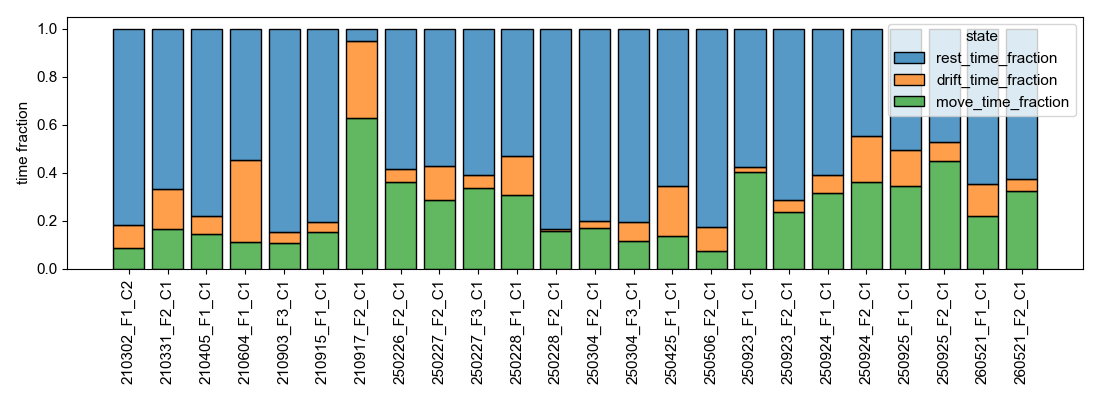

In [14]:
columns = ['rest_time_fraction','drift_time_fraction','move_time_fraction']
long = (op_cond_df[columns].rename_axis('dfc').reset_index()
        .melt(id_vars='dfc', var_name='state', value_name='frac'))
plt.figure(figsize=(11, 4))
ax = sns.histplot(data=long, x='dfc', hue='state', weights='frac',
                  multiple='stack', shrink=0.8, hue_order=columns)
ax.set_ylabel('time fraction'); ax.set_xlabel('')
plt.xticks(rotation=90)
plt.tight_layout()

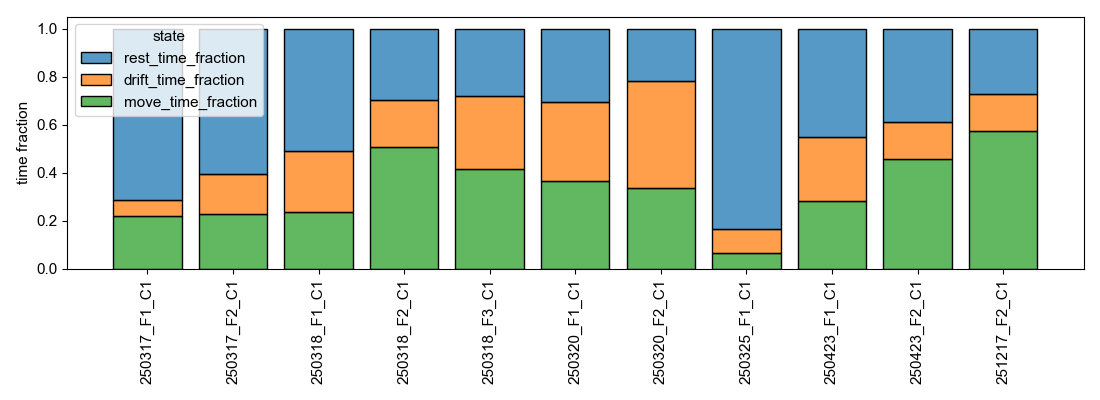

In [15]:
columns = ['rest_time_fraction','drift_time_fraction','move_time_fraction']
long = (iav_df[columns].rename_axis('dfc').reset_index()
        .melt(id_vars='dfc', var_name='state', value_name='frac'))
plt.figure(figsize=(11, 4))
ax = sns.histplot(data=long, x='dfc', hue='state', weights='frac',
                  multiple='stack', shrink=0.8, hue_order=columns)
ax.set_ylabel('time fraction'); ax.set_xlabel('')
plt.xticks(rotation=90)
plt.tight_layout()

In [16]:
op_cond_df.loc['210917_F2_C1']

Table                                                                          None
parquet                           LEDFlashTriggerPiezoControl_210917_F2_C1_Table...
genotype                                      +;Hot-Cell-LexA_Chr;31H05-GAL4_pJFRC7
notes                             {'text': 'na', 'tags': ['Figure1', 'learn'], '...
duration                                                                 5780.00094
rms_velocity                                                           74683.629443
outcome_fractions_no_as_no_mv                                              0.315498
outcome_fractions_as_off                                                   0.276753
outcome_fractions_rest                                                     0.121771
outcome_fractions_no_as_mv                                                 0.127306
outcome_fractions_probe                                                         0.0
outcome_fractions_as_off_late                                              0

In [17]:
columns = ['rest_time_fraction','drift_time_fraction','move_time_fraction']


def fraction_lines(df, columns=columns, jitter=0.05, title=None, savepath=None,
                   width=950, height=600):
    """Per-fly state fractions as connected dots -- one x per column, one line
    per index entry, thick black median across the un-jittered positions.

    jitter   : half-width of the per-fly x offset. Offsets are spread evenly by
               index order rather than drawn at random, so no two lines land on
               top of each other.
    savepath : .svg / .pdf / .png go through write_image (kaleido), .html
               through write_html.
    """
    off = pd.Series(np.linspace(-jitter, jitter, len(df)), index=df.index)
    long = (df[columns].rename_axis('dfc').reset_index()
            .melt(id_vars='dfc', var_name='state', value_name='frac'))
    long['x'] = long['state'].map({s: i for i, s in enumerate(columns)}) + long['dfc'].map(off)
    long['label'] = np.where(long['state'] == columns[-1], long['dfc'], '')

    fig = px.line(long, x='x', y='frac', color='dfc', markers=True, text='label',
                  hover_name='dfc', template='simple_white', title=title,
                  labels={'frac': 'time fraction', 'x': 'state'})
    fig.update_traces(textposition='middle right', textfont_size=9)

    med = df[columns].median()
    fig.add_scatter(x=list(range(len(columns))), y=med.values, mode='lines+markers',
                    name='median', line=dict(color='black', width=4),
                    marker=dict(color='black', size=11, symbol='diamond'),
                    hovertemplate='median = %{y:.3f}<extra></extra>')

    fig.update_xaxes(tickvals=list(range(len(columns))),
                     ticktext=[s.replace('_time_fraction', '') for s in columns],
                     range=[-0.3, len(columns) - 0.5])
    fig.update_yaxes(range=[0, 1])
    fig.update_layout(width=width, height=height)
    if savepath:
        (fig.write_html if savepath.endswith('.html') else fig.write_image)(savepath)
        print(f'-> {savepath}')
    return fig


fig = fraction_lines(op_cond_df, title=f'learner controls (n={len(op_cond_df)})',
                     savepath=f'{mutant_fig_dir}/state_fraction_lines_learners.svg')
fig.show()

-> Figure5_mutant_plots/state_fraction_lines_learners.svg


In [18]:
fig = fraction_lines(iav_df, title=f'+;iav chordotonal silencing (n={len(iav_df)})',
                     savepath=f'{mutant_fig_dir}/state_fraction_lines_iav.svg')
fig.show()

-> Figure5_mutant_plots/state_fraction_lines_iav.svg


## Is the rest / drift / move trade-off different in `+;iav`?

The three fractions are a **composition** -- they sum to 1, so they carry only
two degrees of freedom and any one of them is fixed by the other two. Testing
`rest`, `drift` and `move` separately therefore re-tests the same information
three times and pays a multiplicity penalty for it. The trade-off itself is the
hypothesis, so it wants a single multivariate test.

Approach: put each fly in Aitchison geometry via two orthonormal ILR balances,

* `ilr1 = sqrt(1/2) log(move/drift)` -- how the non-resting time splits
* `ilr2 = sqrt(2/3) log(rest/sqrt(drift*move))` -- rest vs moving

then run one PERMANOVA (pseudo-F on Aitchison distance) and a permutation
Hotelling T^2 on those coordinates. Both are permutation tests: n ~ 10 per group
is far too small to lean on the F / T^2 reference distributions. Only after a
significant multivariate result do the Holm-corrected univariate follow-ups get
read, and they say *which direction*, not *whether*.

A significant PERMANOVA can also come from unequal spread rather than a shifted
centre, so the dispersion of each group around its own centre is reported
alongside (the PERMDISP idea).

**Groups.** `+;iav` pools Kir2.1 and TeTx -- both silence the same iav-positive
femoral chordotonal neurons. The learner controls are deliberately many
genotypes, since learning is not specific to one background, so heterogeneity
inside that group is intended rather than a confound. `210917_F2_C1` is
excluded: its probe signal carries noise absent from the other recordings, which
corrupts the kinematic state classification -- to be noted in the methods.

In [19]:
# ---------------------------------------------------------------------------
# Compositional comparison of the rest / drift / move trade-off
# ---------------------------------------------------------------------------
# The three fractions are a composition: they sum to 1, so they carry only TWO
# degrees of freedom and one fraction is determined by the other two. Testing
# each separately re-tests the same information and pays a multiplicity penalty
# for it. Instead work in Aitchison geometry -- map each fly to 2 orthonormal
# ILR coordinates, where Euclidean distance IS Aitchison distance -- and do one
# multivariate location test by permutation (n ~ 10 is far too small to trust
# the F or T^2 reference distributions).

def close(x):
    """Renormalise rows to sum 1, after multiplicative replacement of zeros."""
    x = np.asarray(x, float)
    if (x == 0).any():
        x = np.where(x == 0, 0.5 * x[x > 0].min(), x)
    return x / x.sum(axis=-1, keepdims=True)


def ilr3(comp):
    """ILR coordinates of a 3-part composition ordered [rest, drift, move].

    Two interpretable balances:
      ilr1 = sqrt(1/2) log(move/drift)               -- how the moving time splits
      ilr2 = sqrt(2/3) log(rest/sqrt(drift*move))    -- rest vs moving
    They are orthonormal, so Euclidean distance here is Aitchison distance on
    the simplex.
    """
    r, d, m = comp[:, 0], comp[:, 1], comp[:, 2]
    return np.column_stack([np.sqrt(1 / 2) * np.log(m / d),
                            np.sqrt(2 / 3) * np.log(r / np.sqrt(d * m))])


def geo_centre(comp):
    """Closed geometric mean -- the compositional centre (not the arithmetic
    mean, which is biased on the simplex)."""
    return close(np.exp(np.log(comp).mean(axis=0)))


def pseudo_F(Y, g):
    """PERMANOVA pseudo-F on Euclidean (= Aitchison) distance, two groups."""
    a, b = Y[g == 0], Y[g == 1]
    n, k = len(Y), 2
    ss_t = ((Y - Y.mean(0)) ** 2).sum()
    ss_w = ((a - a.mean(0)) ** 2).sum() + ((b - b.mean(0)) ** 2).sum()
    return ((ss_t - ss_w) / (k - 1)) / (ss_w / (n - k))


def hotelling_T2(Y, g):
    a, b = Y[g == 0], Y[g == 1]
    na, nb = len(a), len(b)
    S = ((na - 1) * np.cov(a, rowvar=False)
         + (nb - 1) * np.cov(b, rowvar=False)) / (na + nb - 2)
    d = a.mean(0) - b.mean(0)
    return float(d @ np.linalg.solve(S, d) * na * nb / (na + nb))


def perm_p(stat_fn, Y, g, n_perm=20000, seed=0):
    """Two-group permutation p for a statistic that is large under H1."""
    obs = stat_fn(Y, g)
    rng = np.random.default_rng(seed)
    gp, ge = g.copy(), 0
    for _ in range(n_perm):
        rng.shuffle(gp)
        if stat_fn(Y, gp) >= obs:
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)


def prob_superiority(a, b):
    """P(a > b), ties at 1/2 -- the Mann-Whitney effect size."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    return ((a[:, None] > b[None, :]).sum()
            + 0.5 * (a[:, None] == b[None, :]).sum()) / (len(a) * len(b))


def holm(ps):
    ps = np.asarray(ps, float)
    adj, run = np.empty_like(ps), 0.0
    for i, j in enumerate(np.argsort(ps)):
        run = max(run, (len(ps) - i) * ps[j])
        adj[j] = min(run, 1.0)
    return adj


def compare_compositions(a_df, b_df, name_a, name_b, columns=columns,
                         n_perm=20000, seed=0):
    """One multivariate test of 'is the state trade-off different', plus the
    follow-ups that say which way. Returns the follow-up table.
    """
    A, B = close(a_df[columns].dropna().values), close(b_df[columns].dropna().values)
    Y = ilr3(np.vstack([A, B]))
    g = np.r_[np.zeros(len(A), int), np.ones(len(B), int)]
    short = [c.split('_')[0] for c in columns]

    print(f'{name_a}: n={len(A)}    {name_b}: n={len(B)}')
    print('\ncompositional centre (closed geometric mean)')
    print(pd.DataFrame([geo_centre(A), geo_centre(B)], index=[name_a, name_b],
                       columns=short).to_string(float_format=lambda v: f'{v:.3f}'))
    print('\nAitchison distance between centres: '
          f'{np.linalg.norm(ilr3(geo_centre(A)[None]) - ilr3(geo_centre(B)[None])):.3f}')

    f, pf = perm_p(pseudo_F, Y, g, n_perm, seed)
    t2, pt = perm_p(hotelling_T2, Y, g, n_perm, seed + 1)
    print(f'\nPERMANOVA (Aitchison)  pseudo-F = {f:.2f}   p = {pf:.4f}  ({n_perm} perms)')
    print(f'Hotelling T^2 (perm)   T2 = {t2:.2f}       p = {pt:.4f}')

    # Location shift, or just more scatter? A significant PERMANOVA with
    # different dispersions is ambiguous, so check it explicitly (PERMDISP idea).
    da = np.linalg.norm(Y[g == 0] - Y[g == 0].mean(0), axis=1)
    db = np.linalg.norm(Y[g == 1] - Y[g == 1].mean(0), axis=1)
    print(f'\ndispersion (distance to own centre)  median {name_a} = {np.median(da):.3f}, '
          f'{name_b} = {np.median(db):.3f}   Mann-Whitney p = '
          f'{mannwhitneyu(da, db, alternative="two-sided")[1]:.4f}')

    coords = {'ilr1  log(move/drift)': (ilr3(A)[:, 0], ilr3(B)[:, 0]),
              'ilr2  rest vs moving': (ilr3(A)[:, 1], ilr3(B)[:, 1])}
    coords.update({c: (A[:, i], B[:, i]) for i, c in enumerate(columns)})
    rows = []
    for k, (va, vb) in coords.items():
        rows.append({'measure': k, f'median {name_a}': np.median(va),
                     f'median {name_b}': np.median(vb),
                     'P(sup)': prob_superiority(vb, va),
                     'p': mannwhitneyu(va, vb, alternative='two-sided')[1]})
    out = pd.DataFrame(rows)
    out['p_holm'] = holm(out['p'])
    print(f'\nfollow-ups (Mann-Whitney, Holm over the {len(out)} rows; '
          f'P(sup) = P({name_b} > {name_a}))')
    print(out.to_string(index=False, float_format=lambda v: f'{v:.4g}'))
    return out

In [20]:
# --- groups for the test ----------------------------------------------------
# +;iav pools Kir2.1 and TeTx: both silence the same iav-positive femoral
# chordotonal neurons, so they are one manipulation for this question.
iav_stat_df = iav_df

# The learner controls are many genotypes by design -- learning is not specific
# to one background -- so genotype heterogeneity inside this group is intended,
# not a confound. (The w background is a different matter: it affects learning
# strongly and is not in dataset_1.)
EXCLUDE_FROM_STATS = {
    # Probe signal carries noise absent from the other recordings, which
    # corrupts the kinematic state classification. Note the exclusion in methods.
    '210917_F2_C1': 'noisy probe signal -> unreliable kinematic states',
    # Same TH-GAL4 > UAS-Kir2.1 genotype as the fly already pulled out of
    # dataset_1. Uncomment to drop it too; the result is unchanged either way.
    # '250506_F2_C1': 'TH-GAL4 > UAS-Kir2.1 is itself a silencing line',
}
drop = [d for d in EXCLUDE_FROM_STATS if d in op_cond_df.index]
for d in drop:
    print(f'excluded {d}  ({op_cond_df.at[d, "genotype"]}) -- {EXCLUDE_FROM_STATS[d]}')
ctrl_stat_df = op_cond_df.drop(index=drop)

res = compare_compositions(ctrl_stat_df, iav_stat_df, 'learner ctrl', '+;iav')

excluded 210917_F2_C1  (+;Hot-Cell-LexA_Chr;31H05-GAL4_pJFRC7) -- noisy probe signal -> unreliable kinematic states
learner ctrl: n=23    +;iav: n=11

compositional centre (closed geometric mean)
              rest  drift  move
learner ctrl 0.699  0.083 0.218
+;iav        0.454  0.217 0.329

Aitchison distance between centres: 0.993

PERMANOVA (Aitchison)  pseudo-F = 9.28   p = 0.0005  (20000 perms)
Hotelling T^2 (perm)   T2 = 17.68       p = 0.0008

dispersion (distance to own centre)  median learner ctrl = 0.684, +;iav = 0.610   Mann-Whitney p = 0.4843

follow-ups (Mann-Whitney, Holm over the 5 rows; P(sup) = P(+;iav > learner ctrl))
              measure  median learner ctrl  median +;iav  P(sup)        p   p_holm
ilr1  log(move/drift)               0.5474        0.2089  0.3281   0.1134   0.1209
 ilr2  rest vs moving                1.241        0.3268  0.1581 0.001546 0.007731
   rest_time_fraction               0.6485        0.3916  0.1897 0.004087  0.01226
  drift_time_fraction   

## Threshold explorer

Interactive version of the `plot_bouts` HTMLs, with a slider over
`(speed_kind, v_th, v_rest)` so the state boundaries can be tuned by eye.

**How the states are actually assigned** (`kin._classify_states_schmitt`,
reproduced in `_states_from_speed` and verified identical):

1. **MOVE** — entered when `speed >= v_th`; left only on a run of `>= Dt`
   (0.2 s) with `speed < v_rest`. Shorter dips are absorbed: that is the
   hysteresis. A MOVE run whose position peak-to-peak is under
   `x_excursion_min` (8 µm) is demoted to DRIFT wholesale.
2. **REST / DRIFT** — everything not MOVE. A sample is REST iff it sits in a
   run of `>= Dt` with `speed < v_rest`; otherwise DRIFT.

So **there is no REST→DRIFT transition rule.** DRIFT is the residual state, and
both REST and DRIFT are carved out of the non-MOVE remainder by the same
`v_rest` test. A sample flips REST→DRIFT the instant speed rises above `v_rest`,
or when a sub-`v_rest` run is too short to qualify. Only the MOVE boundary is
hysteretic; the REST/DRIFT boundary is a hard threshold.

**Which knob does what:**

* `v_th` moves the MOVE↔DRIFT boundary — *this* is the one for making movement
  read as drift.
* `v_rest` moves the DRIFT↔REST boundary. Raising it does **not** convert move
  into drift, it converts drift into rest.
* `speed_kind` picks the primitive being thresholded. `'rms'` is what kin uses
  (`_rolling_rms`), and it includes jitter power — on this fly its median is
  ~41 µm/s while the mean-based speed is ~9 µm/s, which is why slow slides clear
  `v_th=60` on jitter alone. `'mean'` thresholds `|boxcar mean|`, so zero-mean
  jitter averages out. Its thresholds need to be ~4-5x lower.

Caution: setting `v_rest` very low makes MOVE unable to exit (it needs a 0.2 s
run below `v_rest`), so it latches for the whole trace — `mean 20/5` in the
default grid gives move = 1.000 as a demonstration.

In [21]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

import mapd.kinematics as kin

STATE_NAMES = {kin.STATE_REST: 'rest', kin.STATE_DRIFT: 'drift', kin.STATE_MOVE: 'move'}


def _boxcar(a, n):
    """Centred boxcar mean with edge padding (no zero-pull at the ends)."""
    if n <= 1:
        return np.asarray(a, float)
    pad = np.pad(np.asarray(a, float), (n // 2, n - n // 2), mode='edge')
    return np.convolve(pad, np.ones(n) / n, mode='valid')[:len(a)]


def compute_speed(v, fs, smooth_window=0.05, speed_kind='rms'):
    """Speed signal the thresholds are compared against.

    'rms'  : kin's own -- _rolling_rms(v, n). Includes jitter power, so a
             motionless-but-noisy trace still reads tens of um/s.
    'mean' : |centred boxcar mean of v|. Zero-mean jitter averages out, so this
             reflects net rate of travel.
    """
    n = max(1, int(round(smooth_window * fs)))
    if speed_kind == 'rms':
        return kin._rolling_rms(v, n)
    if speed_kind == 'mean':
        return np.abs(_boxcar(v, n))
    raise ValueError(f'unknown speed_kind {speed_kind!r}')


def _states_from_speed(speed, x, v_th, v_rest, n_rest, x_excursion_min=8.0):
    """kin._classify_states_schmitt's logic, on a precomputed speed array.

    Pass 1 -- MOVE via Schmitt trigger:
        enter MOVE when speed >= v_th;
        leave MOVE only on a run of >= n_rest samples with speed < v_rest
        (shorter dips are absorbed -- that is the hysteresis);
        a MOVE run whose position peak-to-peak is < x_excursion_min is demoted
        to DRIFT wholesale.

    Pass 2 -- everything not MOVE is REST or DRIFT:
        REST iff inside a run of >= n_rest samples with speed < v_rest;
        DRIFT otherwise.

    So DRIFT is the RESIDUAL state, and there is no REST->DRIFT transition
    rule: both are carved out of the non-MOVE remainder by the same v_rest
    test. A sample flips REST->DRIFT the moment speed rises above v_rest (or
    the sub-v_rest run is too short to qualify). Only the MOVE boundary is
    hysteretic; the REST/DRIFT boundary is a hard threshold at v_rest.
    """
    n = len(speed)
    state = np.full(n, kin.STATE_DRIFT, dtype=np.int8)
    in_move, i = False, 0
    move_start = 0

    while i < n:
        if not in_move:
            if speed[i] >= v_th:
                in_move, move_start = True, i
                state[i] = kin.STATE_MOVE
            i += 1
        else:
            state[i] = kin.STATE_MOVE
            if speed[i] < v_rest:
                quiet_start, j = i, i + 1
                while j < n and speed[j] < v_rest:
                    j += 1
                if j - quiet_start >= n_rest:
                    state[quiet_start:j] = kin.STATE_DRIFT
                    if x_excursion_min is not None and x is not None:
                        if np.ptp(x[move_start:quiet_start]) < x_excursion_min:
                            state[move_start:quiet_start] = kin.STATE_DRIFT
                    in_move, i = False, j
                else:
                    state[quiet_start:j] = kin.STATE_MOVE
                    i = j
            else:
                i += 1
    if in_move and x_excursion_min is not None and x is not None:
        if np.ptp(x[move_start:]) < x_excursion_min:
            state[move_start:] = kin.STATE_DRIFT

    i = 0
    while i < n:
        if state[i] != kin.STATE_MOVE:
            j = i + 1
            while j < n and state[j] != kin.STATE_MOVE:
                j += 1
            k = i
            while k < j:
                if speed[k] < v_rest:
                    rs, m = k, k + 1
                    while m < j and speed[m] < v_rest:
                        m += 1
                    if m - rs >= n_rest:
                        state[rs:m] = kin.STATE_REST
                    k = m
                else:
                    k += 1
            i = j
        else:
            i += 1
    return state


def classify(t, x, v_th, v_rest, Dt=0.2, smooth_window=0.05,
             speed_kind='rms', x_excursion_min=8.0):
    """Full path: t,x -> (speed, states), mirroring detect_movement_bouts' preprocessing."""
    fs = 1.0 / np.median(np.diff(t))
    v = kin.velocity(t, x)
    v = kin._zero_short_dt_velocity(v, t, smooth_window, fs)
    speed = compute_speed(v, fs, smooth_window, speed_kind)
    n_rest = max(1, int(round(Dt * fs)))
    states = _states_from_speed(speed, x, v_th, v_rest, n_rest, x_excursion_min)
    return speed, states


def default_grid():
    """Threshold combos worth looking at. 'mean' speed runs ~5x lower than 'rms',
    so it gets its own, lower, threshold ladder."""
    combos = []
    for v_th, v_rest in [(60, 30), (100, 30), (100, 60), (150, 60),
                         (250, 60), (250, 100)]:
        combos.append(dict(speed_kind='rms', v_th=v_th, v_rest=v_rest))
    for v_th, v_rest in [(20, 5), (20, 10), (40, 10), (40, 20), (60, 20), (60, 30)]:
        combos.append(dict(speed_kind='mean', v_th=v_th, v_rest=v_rest))
    return combos


def plotly_threshold_explorer(trials, combos=None, Dt=0.2, smooth_window=0.05,
                              x_excursion_min=8.0, savepath=None,
                              title=None, height=760, width=1150):
    """Slider over threshold combos; each step re-colours the trace by state.

    Row 1: probe position, split into rest/drift/move traces (more force = up),
           with the target band.
    Row 2: the speed signal actually being thresholded, with v_th / v_rest drawn
           in, so you can see how much of the slide sits above v_th.

    Self-contained HTML -- all combos are precomputed, the slider just toggles
    visibility. No kernel needed once written.
    """
    combos = combos or default_grid()
    t, x, _ = build_trace_with_boundaries(trials)
    t = np.asarray(t) - t[0]
    x = np.asarray(x)

    tr0 = trials[0]
    tgt_hi = -(float(tr0.pyasXPosition) - float(tr0.probeZero))
    tgt_lo = tgt_hi - float(tr0.pyasWidth)

    fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                        row_heights=[0.62, 0.38], vertical_spacing=0.07,
                        subplot_titles=('probe position', 'speed being thresholded'))

    # one speed trace per distinct speed_kind
    kinds = sorted({c['speed_kind'] for c in combos})
    speed_by_kind = {}
    for k in kinds:
        speed_by_kind[k], _ = classify(t, x, 1e9, 1e9, Dt, smooth_window, k,
                                       x_excursion_min)

    idx = {}
    for k in kinds:
        fig.add_trace(go.Scatter(x=t, y=speed_by_kind[k], mode='lines',
                                 line=dict(color='#444', width=0.7),
                                 name=f'speed ({k})', showlegend=False,
                                 hovertemplate='%{y:.0f} µm/s<extra></extra>'),
                      row=2, col=1)
        idx[('speed', k)] = len(fig.data) - 1

    frac_labels = []
    for ci, c in enumerate(combos):
        speed, states = classify(t, x, c['v_th'], c['v_rest'], Dt,
                                 smooth_window, c['speed_kind'], x_excursion_min)
        for st in (kin.STATE_REST, kin.STATE_DRIFT, kin.STATE_MOVE):
            y = np.where(states == st, x, np.nan)
            fig.add_trace(go.Scatter(
                x=t, y=y, mode='lines',
                line=dict(color=kin._STATE_COLORS[st], width=1.2),
                name=STATE_NAMES[st], legendgroup=STATE_NAMES[st],
                showlegend=(ci == 0), visible=(ci == 0),
                hovertemplate='%{y:.0f} µm<extra>' + STATE_NAMES[st] + '</extra>'),
                row=1, col=1)
            idx[(ci, st)] = len(fig.data) - 1
        for nm, val, dash in (('v_th', c['v_th'], 'solid'), ('v_rest', c['v_rest'], 'dot')):
            fig.add_trace(go.Scatter(
                x=[t[0], t[-1]], y=[val, val], mode='lines',
                line=dict(color='#c0504d' if nm == 'v_th' else '#4d79c0',
                          width=1.2, dash=dash),
                name=nm, showlegend=(ci == 0), visible=(ci == 0),
                hovertemplate=f'{nm}={val}<extra></extra>'), row=2, col=1)
            idx[(ci, nm)] = len(fig.data) - 1
        fr = {STATE_NAMES[s]: float(np.mean(states == s))
              for s in (kin.STATE_REST, kin.STATE_DRIFT, kin.STATE_MOVE)}
        frac_labels.append(fr)

    steps = []
    for ci, c in enumerate(combos):
        vis = [False] * len(fig.data)
        vis[idx[('speed', c['speed_kind'])]] = True
        for st in (kin.STATE_REST, kin.STATE_DRIFT, kin.STATE_MOVE):
            vis[idx[(ci, st)]] = True
        vis[idx[(ci, 'v_th')]] = True
        vis[idx[(ci, 'v_rest')]] = True
        fr = frac_labels[ci]
        steps.append(dict(
            method='update', label=f"{c['speed_kind']} {c['v_th']}/{c['v_rest']}",
            args=[{'visible': vis},
                  {'title': (f"{title or ''}   speed={c['speed_kind']}  "
                             f"v_th={c['v_th']}  v_rest={c['v_rest']}  |  "
                             f"rest {fr['rest']:.2f}  drift {fr['drift']:.2f}  "
                             f"move {fr['move']:.2f}")}]))

    c0, f0 = combos[0], frac_labels[0]
    fig.update_layout(
        height=height, width=width, template='simple_white',
        title=(f"{title or ''}   speed={c0['speed_kind']}  v_th={c0['v_th']}  "
               f"v_rest={c0['v_rest']}  |  rest {f0['rest']:.2f}  "
               f"drift {f0['drift']:.2f}  move {f0['move']:.2f}"),
        sliders=[dict(active=0, steps=steps, x=0.02, len=0.96, y=-0.02,
                      currentvalue=dict(prefix='thresholds: '))],
        margin=dict(l=70, r=40, t=80, b=110), font=dict(size=12),
        hovermode='x unified',
    )
    fig.add_hrect(y0=tgt_lo, y1=tgt_hi, fillcolor='#f6c1cd', opacity=0.5,
                  line_width=0, layer='below', row=1, col=1)
    fig.update_yaxes(title_text='probe position (µm)  more force →', row=1, col=1)
    fig.update_yaxes(title_text='speed (µm/s)', type='log', row=2, col=1)
    fig.update_xaxes(title_text='time (s)', row=2, col=1)

    if savepath:
        fig.write_html(savepath)
        print(f'-> {savepath}')
    return fig


#   To return to an earlier question about the threshold, the interactive routine you wrote into the html figure seems
#   to have a bug. The movement filtering shifts, it initially looks different, then changes.
# ────────────────────────────────────────────────────────────────────────────────────────────────

In [22]:
trials_261 = load_trial_run('250320_F1_C1', 261, 262)

fig_expl = plotly_threshold_explorer(
    trials_261, title='250320_F1_C1 trials 261-262',
    savepath=f'{mutant_fig_dir}/250320_F1_C1/threshold_explorer_trial_261.html')
fig_expl.show()

# state fractions across the whole grid, to compare settings numerically
_t, _x, _ = build_trace_with_boundaries(trials_261)
rows = []
for c in default_grid():
    _, st = classify(_t, _x, c['v_th'], c['v_rest'], speed_kind=c['speed_kind'])
    rows.append({**c,
                 'rest': np.mean(st == kin.STATE_REST),
                 'drift': np.mean(st == kin.STATE_DRIFT),
                 'move': np.mean(st == kin.STATE_MOVE)})
pd.DataFrame(rows)

-> Figure5_mutant_plots/250320_F1_C1/threshold_explorer_trial_261.html


,speed_kind,v_th,v_rest,rest,drift,move
0,rms,60,30,0.088912,0.322177,0.588912
1,rms,100,30,0.088912,0.464997,0.446091
2,rms,100,60,0.603219,0.127491,0.269290
3,rms,150,60,0.603219,0.163771,0.233010
4,rms,250,60,0.603219,0.163771,0.233010
5,rms,250,100,0.776955,0.015330,0.207716
6,mean,20,5,0.000000,0.000000,1.000000
7,mean,20,10,0.101686,0.219213,0.679101
8,mean,40,10,0.101686,0.318855,0.579458
9,mean,40,20,0.442259,0.124681,0.433061


# In-target move duration

Once the probe is **inside the current trial's target band**, how long does the
fly keep moving? `mapd.bout_analysis` now carries the primitives:

* `ba.target_bounds(trial)` -- the band in the flipped frame
  (`hi = -(pyasXPosition - probeZero)`, `lo = hi - pyasWidth`). Verified to
  select exactly the same samples as `Trial.on_target`'s raw-frame test.
* `ba.trial_in_target_moves(trial)` -- contiguous runs that are simultaneously
  MOVE **and** inside the band, plus per-trial totals.
* `ba.collect_in_target_moves(T)` / `ba.collect_in_target_moves_sinq(sinq)` --
  the same, over a Table or a whole cohort.

States are classified on the full trace (`kin.detect_movement_bouts`, so
`v_th` / `v_rest` carry over from the threshold explorer above); the target
test and the `t_min=0.0` post-stim window are applied afterwards as sample
masks. Each run records **why it ended** -- `exit_target` (still moving when it
left the band, i.e. moved *through* the target) vs `state_change` (the movement
stopped while still inside it).

Starting with the `+;iav` flies, kept separate from `w;iav` for the reason
given further up.

In [23]:
# T = sinq_g.restore_table(dayflycell='250320_F1_C1')

In [24]:
import mapd.bout_analysis as ba

IN_TGT_PREFIX = f'{mutant_fig_dir}/in_target_moves'


def collect_in_target_group(sinq, dfcs, tag, recompute=False, **kwargs):
    """Cached ba.collect_in_target_moves_sinq -- the traces take ~1.5 min/fly.

    Writes {IN_TGT_PREFIX}_{tag}_{runs,trials}.parquet and reads them back on
    later runs. Pass recompute=True after changing v_th / v_rest / t_min.
    """
    runs_p = f'{IN_TGT_PREFIX}_{tag}_runs.parquet'
    trials_p = f'{IN_TGT_PREFIX}_{tag}_trials.parquet'
    if not recompute and os.path.exists(runs_p) and os.path.exists(trials_p):
        print(f'reading cached {tag}')
        return pd.read_parquet(runs_p), pd.read_parquet(trials_p)

    runs, trials = ba.collect_in_target_moves_sinq(sinq, dfcs=list(dfcs), **kwargs)
    if 'genotype' in sinq.df.columns:
        for d in (runs, trials):
            d['genotype'] = d['dfc'].map(sinq.df['genotype'])
    runs.to_parquet(runs_p)
    trials.to_parquet(trials_p)
    return runs, trials


iav_dfcs = sinq_g.df.index[sinq_g.has_tag('+') & sinq_g.has_tag('iav')]
iav_runs, iav_trials = collect_in_target_group(sinq_g, iav_dfcs, 'iav',
                                               recompute=True,
                                               across_trials=True,
                                               state_sets=(kin.STATE_MOVE, ba.STATES_ACTIVE),
                                               verbose=True)

op_cond_dfcs = sinq_1.df.index
op_cond_runs, op_cond_trials = collect_in_target_group(sinq_1, op_cond_dfcs, 'op_cond',
                                                       recompute=True,
                                                       across_trials=True,
                                                       state_sets=(kin.STATE_MOVE, ba.STATES_ACTIVE),
                                                       verbose=True)


[1/11] 250317_F1_C1
Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\250317\\250317_F1_C1\\LEDFlashTriggerPiezoControl_250317_F1_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=216, 250317_F1_C1, dT=10.07614, ex=True), Trial(trial=907, 250317_F1_C1, dT=4.59582, ex=True)]
Getting all meta keys
['as_outcome', 'fiberLED', 'filtercube_status']
Found 2 target positions - Counter({('hi', 630.0, 350.0, -280.0, 60.0): 455, ('lo', 630.0, 450.0, -180.0, 60.0): 450})
[2/11] 250317_F2_C1
Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\250317\\250317_F2_C1\\LEDFlashTriggerPiezoControl_250317_F2_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=311, 250317_F2_C1, dT=10.37336, ex=True), Trial(trial=312, 250317_F2_C1, dT=9.40216, ex=True), Trial(trial=313, 250317_F2_C1, dT=9.41102, ex=True), Trial(trial=314, 250317_F2_C1, dT=8.2687, ex=True), Trial(trial=315, 250317_F2_C1, dT=9.88058, ex=True), Trial(trial=316, 250317_F2_C1, dT=10.31806, ex=True

In [25]:

print(iav_runs.shape, iav_trials.shape)
print(iav_runs.groupby('genotype')['dfc'].nunique().to_string())
# iav_runs.head()

print(op_cond_runs.shape, op_cond_trials.shape)
print(op_cond_runs.groupby('genotype')['dfc'].nunique().to_string())
op_cond_runs.head()


(57048, 30) (12632, 17)
genotype
+;iav-GAL4_UAS-Kir21    10
iav_UAS-TeTx             1
(154460, 30) (38132, 17)
genotype
+;Hot-Cell-LexA_Chr;31H05-GAL4_pJFRC7     1
+;Hot-Cell-LexA_Chr;35C09-GAL4_pJFRC7     2
+;Hot-Cell-LexA_Chr;78E05-GAL4_pJFRC7     1
+;Hot-Cell-LexA_Chr;81A06-GAL4_pJFRC7     2
+;SS61350_pJFRC7                         14
+;UAS-Kir21;TH-GAL4                       1
+;pJFRC7;31H05-GAL4                       1
+;pJFRC7;31H05-Gal4                       1
Hot-Cell-Gal4 (test)                      1


,dfc,state_set,trial,trial_start,trial_end,n_trials,crosses_boundary,chunk,duration,n_samples,...,drift_time,n_move,n_drift,frac_move,run_kind,ends_by,starts_by,as_outcome,pyasState,genotype
0,210302_F1_C2,move,3,3,3,1,False,0,0.458641,91,...,0.0,91,0,1.0,move,exit_target,enter_target,as_off_late,hi,Hot-Cell-Gal4 (test)
1,210302_F1_C2,move,3,3,3,1,False,0,0.393121,78,...,0.0,78,0,1.0,move,state_change,enter_target,as_off_late,hi,Hot-Cell-Gal4 (test)
2,210302_F1_C2,move,4,4,4,1,False,0,0.383041,76,...,0.0,76,0,1.0,move,state_change,enter_target,as_off_late,hi,Hot-Cell-Gal4 (test)
3,210302_F1_C2,move,8,8,8,1,False,0,0.131040,26,...,0.0,26,0,1.0,move,exit_target,state_change,as_off,hi,Hot-Cell-Gal4 (test)
4,210302_F1_C2,move,9,9,9,1,False,0,0.166320,33,...,0.0,33,0,1.0,move,state_change,state_change,as_off_late,hi,Hot-Cell-Gal4 (test)


In [ ]:
iav_runs

In [26]:
iav_runs.dfc.unique()
iav_runs.state_set.unique()

array(['move', 'drift+move'], dtype=object)

In [30]:
iav_trials

,dfc,state_set,trial,chunk,window_time,in_target_time,move_time,in_target_move_time,in_target_move_only_time,in_target_drift_only_time,n_runs,dt,target_lo,target_hi,as_outcome,pyasState,genotype
0,250317_F1_C1,move,1,0,10.06502,0.040000,3.940008,0.040000,0.040000,0.0,2,0.00500,220.0,280.0,as_off,hi,+;iav-GAL4_UAS-Kir21
1,250317_F1_C1,move,2,0,11.33016,0.190760,6.952712,0.190760,0.190760,0.0,13,0.00502,220.0,280.0,as_off,hi,+;iav-GAL4_UAS-Kir21
2,250317_F1_C1,move,3,0,9.22298,0.527881,7.320616,0.527881,0.527881,0.0,20,0.00498,220.0,280.0,as_off,hi,+;iav-GAL4_UAS-Kir21
3,250317_F1_C1,move,4,0,10.69502,0.120000,4.650009,0.120000,0.120000,0.0,10,0.00500,220.0,280.0,as_off,hi,+;iav-GAL4_UAS-Kir21
4,250317_F1_C1,move,5,0,8.57502,0.695002,4.800011,0.695002,0.695002,0.0,5,0.00500,220.0,280.0,as_off_late,hi,+;iav-GAL4_UAS-Kir21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12627,251217_F2_C1,drift+move,603,0,7.93162,0.256021,7.931620,0.256021,0.256021,0.0,18,0.00502,220.0,280.0,as_off,hi,iav_UAS-TeTx
12628,251217_F2_C1,drift+move,604,0,9.85502,0.130000,6.070012,0.130000,0.130000,0.0,4,0.00500,220.0,280.0,as_off,hi,iav_UAS-TeTx
12629,251217_F2_C1,drift+move,605,0,8.90502,0.125000,7.770017,0.125000,0.125000,0.0,16,0.00500,220.0,280.0,as_off,hi,iav_UAS-TeTx
12630,251217_F2_C1,drift+move,606,0,8.34152,0.129480,7.992919,0.129480,0.129480,0.0,16,0.00498,220.0,280.0,as_off,hi,iav_UAS-TeTx


wrote Figure5_mutant_plots/in_target_durations_iav.svg
wrote Figure5_mutant_plots/in_target_durations_op_cond.svg


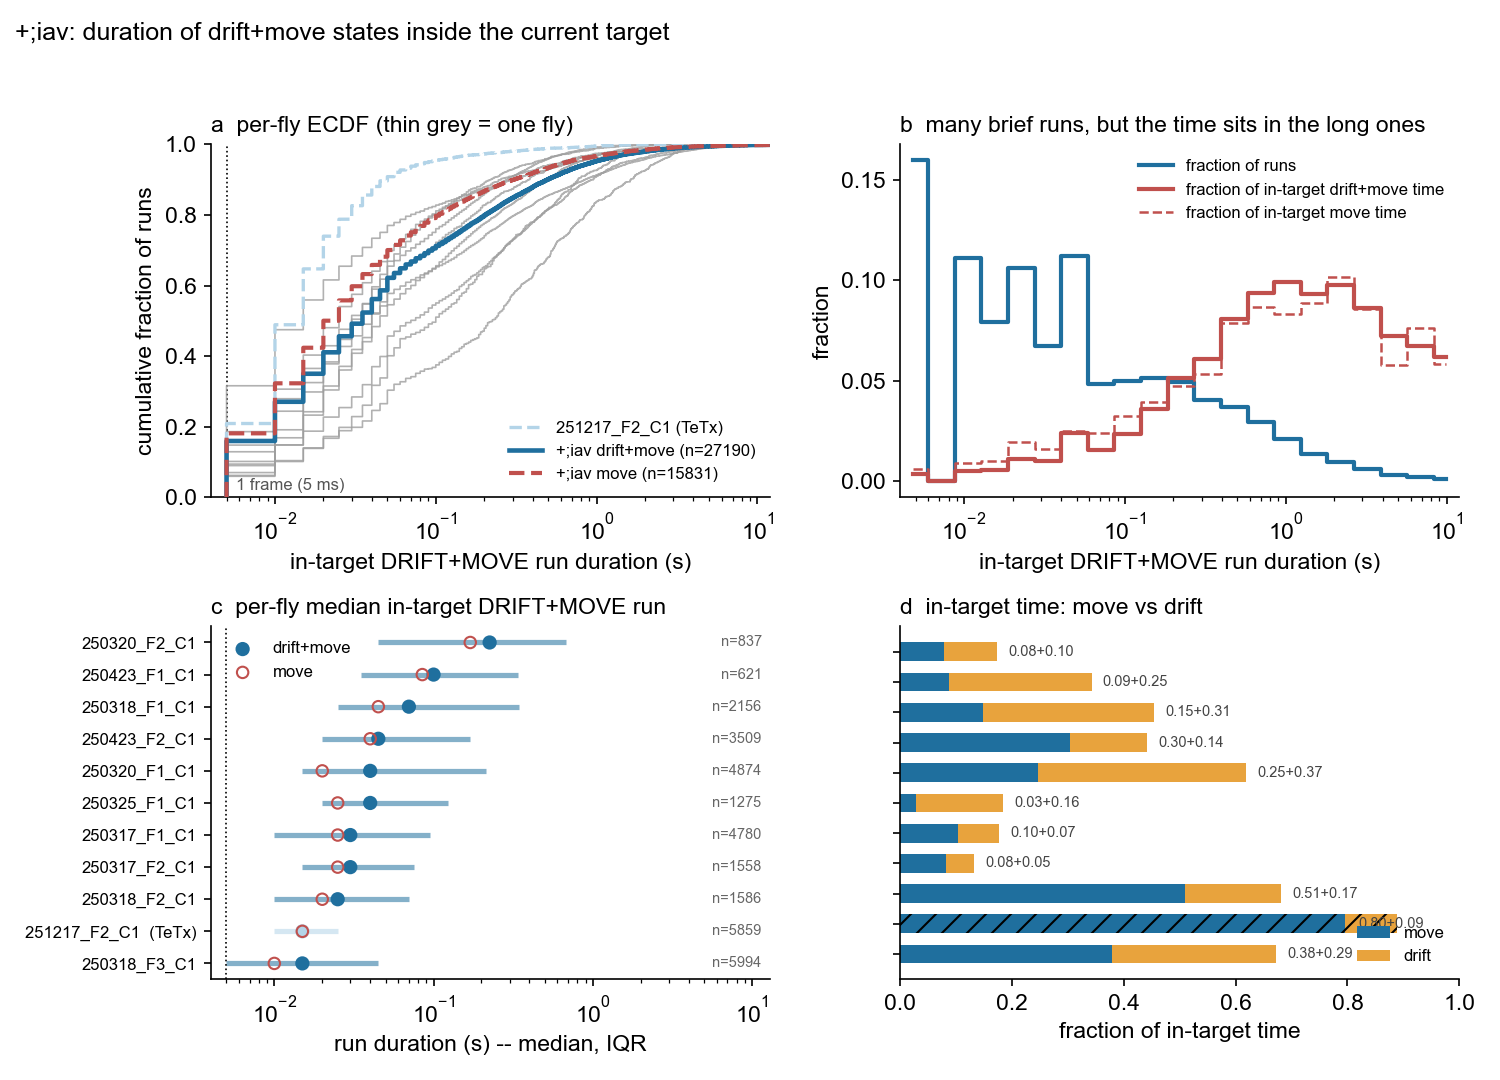

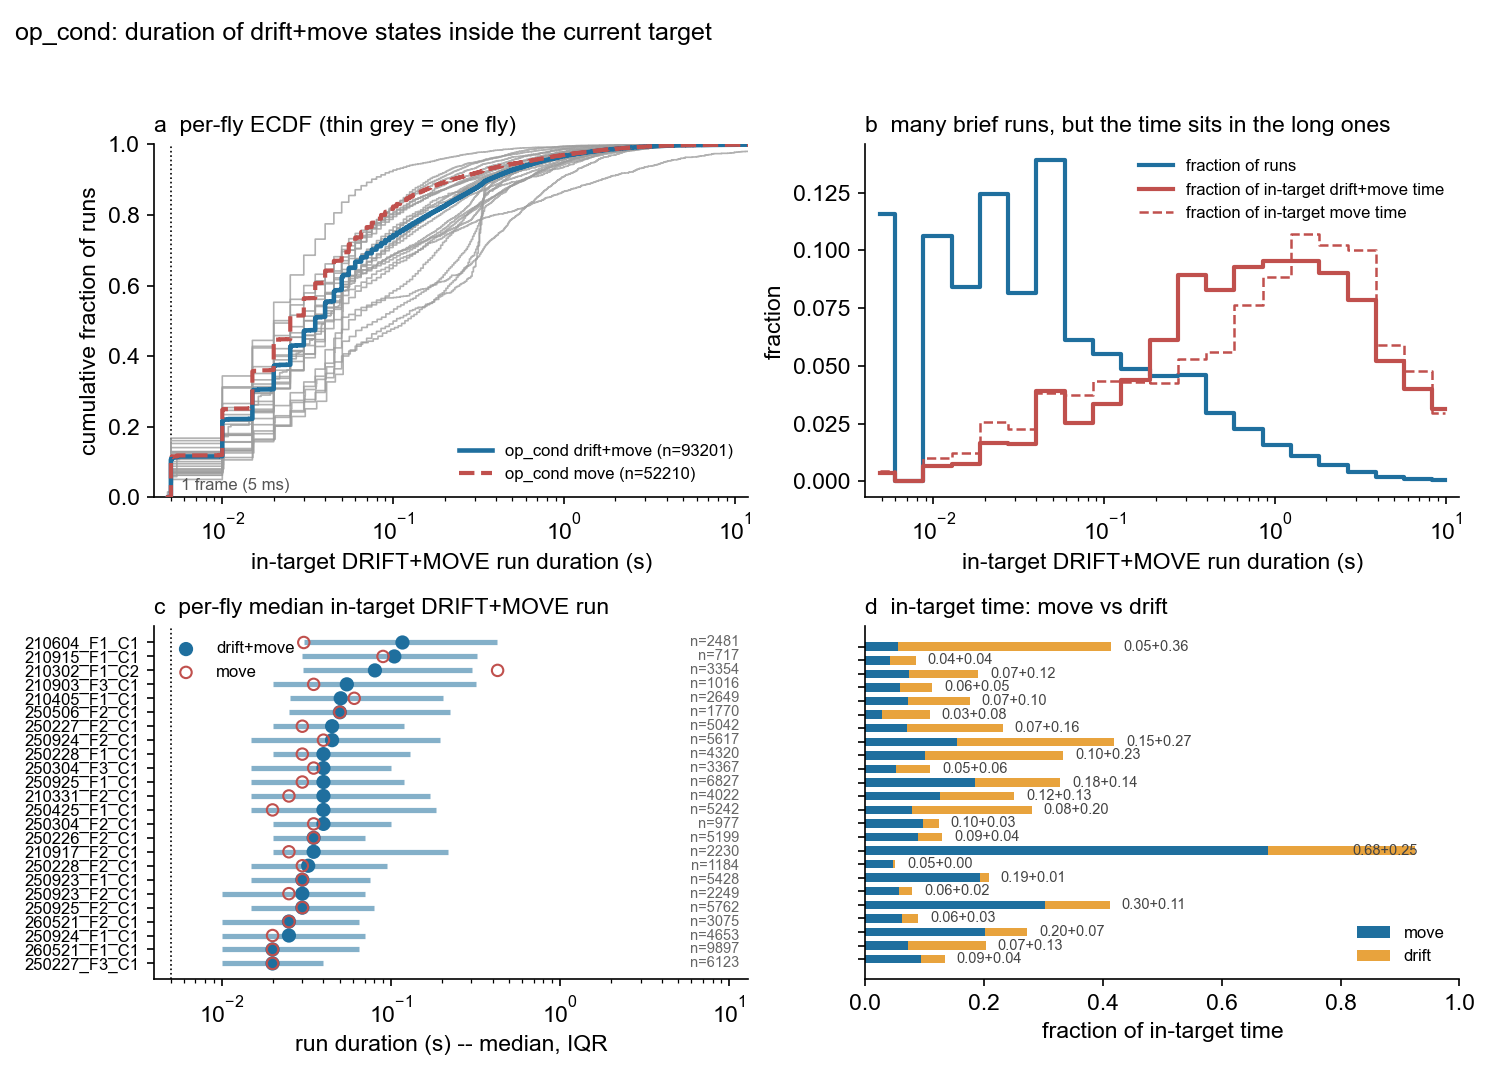

In [29]:

# ---------------------------------------------------------------------------
# Distribution of in-target run durations (MOVE, or DRIFT+MOVE)
# ---------------------------------------------------------------------------
C_MAIN, C_ALT, C_GRAY, C_TIME = '#1f6f9e', '#b3d4e8', '#9e9e9e', '#c0504d'
C_DRIFT = '#e8a33d'

# Non-task trials have a nominal target but no stimulus -- drop them.
NON_TASK_OUTCOMES = ('rest', 'info')


def _split_alt(runs, alt_dfcs=None, alt_marker='TeTx'):
    """Flies to draw separately. Defaults to any genotype carrying alt_marker,
    so the single +;iav TeTx fly does not sit inside the Kir2.1 pooled curve.
    """
    if alt_dfcs is not None:
        return set(alt_dfcs)
    if 'genotype' not in runs.columns:
        return set()
    hit = runs['genotype'].fillna('').str.contains(alt_marker)
    return set(runs.loc[hit, 'dfc'].unique())


def _ecdf(v):
    v = np.sort(np.asarray(v, dtype=float))
    if not len(v):
        return v, v
    return v, np.arange(1, len(v) + 1) / len(v)


def _pick_state_set(df, state_set, what):
    """One state set's rows. Refuses to pool two sets by accident."""
    if 'state_set' not in df.columns:
        return df, 'move'
    have = list(pd.unique(df['state_set'].dropna()))
    if state_set is None:
        if len(have) > 1:
            raise ValueError(
                f'{what} carries {len(have)} state sets {have}; pass '
                f'state_set= to choose one, else the panels pool them.')
        return df, (have[0] if have else 'move')
    out = df[df['state_set'] == state_set]
    if out.empty:
        raise ValueError(f'no {what} rows with state_set={state_set!r}; have {have}')
    return out, state_set


def plot_in_target_durations(runs, trials, group_name='+;iav',
                             state_set=None, compare_state_set=None,
                             exclude_outcomes=NON_TASK_OUTCOMES,
                             alt_dfcs=None, alt_label='TeTx', savepath=None):
    """Four-panel view of how long in-target runs last.

    state_set          which set to draw ('move', 'drift+move'). Required when
                       the frames carry both; the labels follow it.
    compare_state_set  optional second set, drawn as a dashed overlay in a-c so
                       the with-/without-drift versions sit on one axis.

    a  per-fly ECDF of run durations (log x), pooled curve in bold
    b  the same pooled data weighted by count vs by time -- these point in
       opposite directions, which is the whole story
    c  per-fly median + IQR, ordered
    d  in-target time split into MOVE and DRIFT (same fly order as c). This
       panel is state-set independent -- the components come from
       in_target_move_only_time / in_target_drift_only_time -- so it answers
       'with or without drift' directly rather than once per set.

    exclude_outcomes is applied to BOTH frames, so panel d's denominator
    matches the runs in panels a-c.
    """
    if exclude_outcomes and 'as_outcome' in runs.columns:
        runs = runs[~runs['as_outcome'].isin(exclude_outcomes)]
        trials = trials[~trials['as_outcome'].isin(exclude_outcomes)]

    all_runs = runs                      # keep both sets for the overlay
    runs, label = _pick_state_set(runs, state_set, 'runs')
    trials, _ = _pick_state_set(trials, state_set, 'trials')
    cmp_runs = cmp_label = None
    if compare_state_set:
        cmp_runs, cmp_label = _pick_state_set(all_runs, compare_state_set, 'runs')

    alt = _split_alt(runs, alt_dfcs)
    dt = float(trials['dt'].median())
    what = f'in-target {label.upper()} run'

    fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(10, 7.2), dpi=150)

    # (a) per-fly ECDFs + pooled
    for dfc, g in runs.groupby('dfc'):
        if dfc in alt:
            axA.step(*_ecdf(g['duration']), where='post', color=C_ALT, lw=1.6,
                     ls='--', zorder=3, label=f'{dfc} ({alt_label})')
        else:
            axA.step(*_ecdf(g['duration']), where='post', color=C_GRAY,
                     lw=0.8, alpha=0.8)
    pooled = runs.loc[~runs['dfc'].isin(alt), 'duration']
    axA.step(*_ecdf(pooled), where='post', color=C_MAIN, lw=2.2, zorder=4,
             label=f'{group_name} {label} (n={len(pooled)})')
    if cmp_runs is not None:
        cmp_pooled = cmp_runs.loc[~cmp_runs['dfc'].isin(alt), 'duration']
        axA.step(*_ecdf(cmp_pooled), where='post', color=C_TIME, lw=2.0,
                 ls='--', zorder=4,
                 label=f'{group_name} {cmp_label} (n={len(cmp_pooled)})')
    axA.axvline(dt, color='k', lw=0.8, ls=':', zorder=1)
    axA.annotate(f'1 frame ({dt*1e3:.0f} ms)', xy=(dt * 1.15, 0.02),
                 fontsize=8, color='#555')
    axA.set_xscale('log')
    axA.set_xlim(dt * 0.8, 12)
    axA.set_ylim(0, 1)
    axA.set_xlabel(f'{what} duration (s)')
    axA.set_ylabel('cumulative fraction of runs')
    axA.set_title('a  per-fly ECDF (thin grey = one fly)', loc='left', fontsize=11)
    axA.legend(frameon=False, fontsize=8, loc='lower right')

    # (b) count-weighted vs time-weighted
    edges = np.logspace(np.log10(dt * 0.8), np.log10(12), 22)
    ctr = np.sqrt(edges[:-1] * edges[1:])
    d = pooled.to_numpy()
    n_h, _ = np.histogram(d, bins=edges)
    t_h, _ = np.histogram(d, bins=edges, weights=d)
    axB.step(ctr, n_h / n_h.sum(), where='mid', color=C_MAIN, lw=2,
             label='fraction of runs')
    axB.step(ctr, t_h / t_h.sum(), where='mid', color=C_TIME, lw=2,
             label=f'fraction of in-target {label} time')
    if cmp_runs is not None:
        dc = cmp_pooled.to_numpy()
        tc, _ = np.histogram(dc, bins=edges, weights=dc)
        axB.step(ctr, tc / tc.sum(), where='mid', color=C_TIME, lw=1.2, ls='--',
                 label=f'fraction of in-target {cmp_label} time')
    axB.set_xscale('log')
    axB.set_xlim(dt * 0.8, 12)
    axB.set_xlabel(f'{what} duration (s)')
    axB.set_ylabel('fraction')
    axB.set_title('b  many brief runs, but the time sits in the long ones',
                  loc='left', fontsize=11)
    axB.legend(frameon=False, fontsize=8)

    # (c) per-fly median + IQR
    g = runs.groupby('dfc')['duration']
    stats = pd.DataFrame({'med': g.median(), 'q1': g.quantile(.25),
                          'q3': g.quantile(.75), 'n': g.size()}).sort_values('med')
    stats['state_set'] = label
    y = np.arange(len(stats))
    cols = [C_ALT if d_ in alt else C_MAIN for d_ in stats.index]
    axC.hlines(y, stats['q1'], stats['q3'], color=cols, lw=2.5, alpha=0.55)
    axC.scatter(stats['med'], y, s=34, color=cols, zorder=3, label=label)
    if cmp_runs is not None:
        cmp_med = cmp_runs.groupby('dfc')['duration'].median().reindex(stats.index)
        axC.scatter(cmp_med.values, y, s=30, facecolors='none',
                    edgecolors=C_TIME, zorder=4, label=cmp_label)
        axC.legend(frameon=False, fontsize=8, loc='upper left')
    axC.set_yticks(y)
    axC.set_yticklabels([f'{d_}{"  (" + alt_label + ")" if d_ in alt else ""}'
                         for d_ in stats.index], fontsize=8)
    axC.axvline(dt, color='k', lw=0.8, ls=':')
    axC.set_xscale('log')
    axC.set_xlim(dt * 0.8, 13)
    axC.set_xlabel('run duration (s) -- median, IQR')
    axC.set_title(f'c  per-fly median {what}', loc='left', fontsize=11)
    for yy, n in zip(y, stats['n']):
        axC.annotate(f'n={int(n)}', xy=(11.5, yy), fontsize=7, color='#666',
                     va='center', ha='right')

    # (d) in-target time split into MOVE and DRIFT
    tg = trials.groupby('dfc')
    denom = tg['in_target_time'].sum()
    if 'in_target_move_only_time' in trials.columns:
        f_move = (tg['in_target_move_only_time'].sum() / denom).reindex(stats.index)
        f_drift = (tg['in_target_drift_only_time'].sum() / denom).reindex(stats.index)
    else:                      # older cache: only the requested set is available
        f_move = (tg['in_target_move_time'].sum() / denom).reindex(stats.index)
        f_drift = pd.Series(0.0, index=stats.index)
    hatches = ['//' if d_ in alt else None for d_ in stats.index]
    axD.barh(y, f_move.values, color=C_MAIN, height=0.62, label='move')
    axD.barh(y, f_drift.values, left=f_move.values, color=C_DRIFT, height=0.62,
             label='drift')
    for bars in (axD.containers[0], axD.containers[1]):
        for bar, h in zip(bars, hatches):
            bar.set_hatch(h)
    axD.set_yticks(y)
    axD.set_yticklabels([])
    axD.set_xlim(0, 1)
    axD.set_xlabel('fraction of in-target time')
    axD.set_title('d  in-target time: move vs drift', loc='left', fontsize=11)
    axD.legend(frameon=False, fontsize=8, loc='lower right')
    for yy, m, dr in zip(y, f_move.values, f_drift.values):
        axD.annotate(f'{m:.2f}+{dr:.2f}', xy=(min(m + dr + 0.02, 0.82), yy),
                     fontsize=7, color='#444', va='center')

    for ax in (axA, axB, axC, axD):
        ax.spines[['top', 'right']].set_visible(False)
    fig.suptitle(f'{group_name}: duration of {label} states inside the current target',
                 x=0.01, ha='left', fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    if savepath:
        fig.savefig(savepath, bbox_inches='tight')
        print('wrote', savepath)
    return fig, stats


fig_itm, iav_stats = plot_in_target_durations(
    iav_runs, iav_trials, group_name='+;iav',
    state_set='drift+move', compare_state_set='move',
    savepath=f'{mutant_fig_dir}/in_target_durations_iav.svg')

fig_op_cond, op_cond_stats = plot_in_target_durations(
    op_cond_runs, op_cond_trials, group_name='op_cond',
    state_set='drift+move', compare_state_set='move',
    savepath=f'{mutant_fig_dir}/in_target_durations_op_cond.svg')


In [35]:
op_cond_trials

,dfc,state_set,trial,chunk,window_time,in_target_time,move_time,in_target_move_time,in_target_move_only_time,in_target_drift_only_time,n_runs,dt,target_lo,target_hi,as_outcome,pyasState,genotype
0,210302_F1_C2,move,1,0,9.82550,0.000000,4.680490,0.000000,0.000000,0.000000,0,0.00588,200.0,280.0,timeout,hi,Hot-Cell-Gal4 (test)
1,210302_F1_C2,move,2,0,11.51306,0.000000,6.615011,0.000000,0.000000,0.000000,0,0.00588,200.0,280.0,timeout,hi,Hot-Cell-Gal4 (test)
2,210302_F1_C2,move,3,0,9.86274,3.119846,6.358093,1.000482,1.000482,0.041440,2,0.00592,200.0,280.0,as_off_late,hi,Hot-Cell-Gal4 (test)
3,210302_F1_C2,move,4,0,22.15586,15.317414,2.287322,0.446880,0.446880,0.793801,1,0.00588,200.0,280.0,as_off_late,hi,Hot-Cell-Gal4 (test)
4,210302_F1_C2,move,5,0,8.02162,7.068498,0.000000,0.000000,0.000000,0.491361,0,0.00592,200.0,280.0,as_off,hi,Hot-Cell-Gal4 (test)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38127,260521_F2_C1,drift+move,746,29,9.14002,2.175005,0.380001,0.310001,0.000000,0.310001,11,0.00500,220.0,280.0,no_as_mv,hi,+;SS61350_pJFRC7
38128,260521_F2_C1,drift+move,747,29,8.00502,0.000000,0.670002,0.000000,0.000000,0.000000,0,0.00500,220.0,280.0,no_as_mv,hi,+;SS61350_pJFRC7
38129,260521_F2_C1,drift+move,748,29,10.22002,0.000000,0.010000,0.000000,0.000000,0.000000,0,0.00500,220.0,280.0,no_as_mv,hi,+;SS61350_pJFRC7
38130,260521_F2_C1,drift+move,749,29,8.39502,0.000000,0.225001,0.000000,0.000000,0.000000,0,0.00500,220.0,280.0,no_as_mv,hi,+;SS61350_pJFRC7



=== +;iav ===
              n_trials  window_time  move_time  drift_time  active_time  in_target_move  in_target_drift  in_target_active
dfc                                                                                                                       
250317_F1_C1       814       8055.2     2130.1       572.0       2702.1           282.3            198.9             481.2
250317_F2_C1       321       3420.2      885.8       490.1       1375.9            93.8             57.5             151.3
250318_F1_C1       405       4134.7     1023.9       963.8       1987.7           310.8            645.8             956.6
250318_F2_C1       217       2411.0     1484.9       296.1       1780.9           403.9            135.6             539.4
250318_F3_C1       582       6486.7     3144.2      1570.5       4714.7           827.3            640.2            1467.5
250320_F1_C1       603       6360.7     2669.9      1780.3       4450.2           727.3           1100.8            1828.1
2

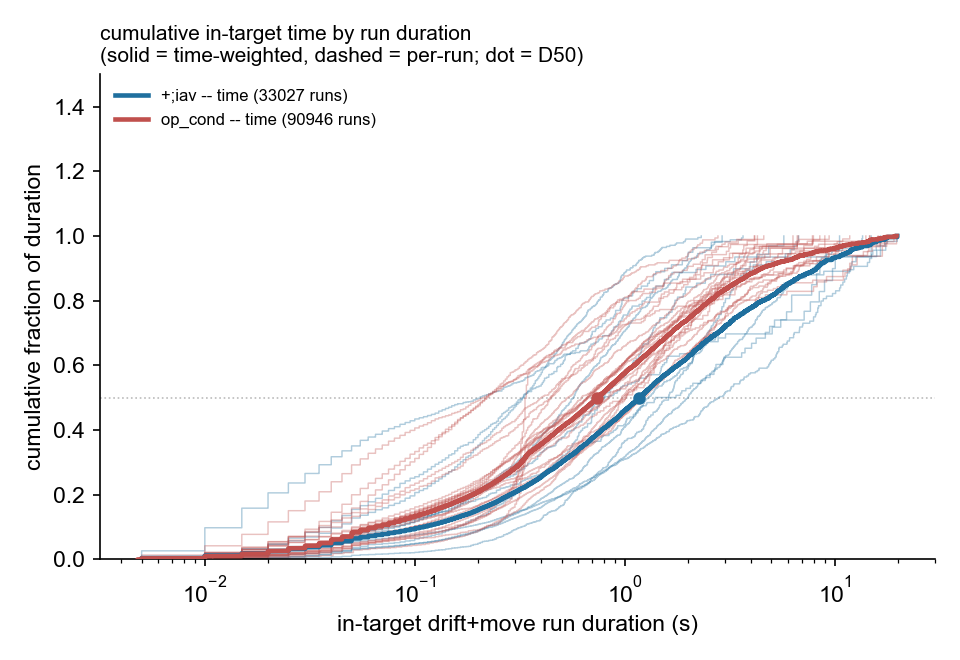

In [79]:
# ---------------------------------------------------------------------------
# Whole-experiment time budget
# ---------------------------------------------------------------------------

def state_time_budget(trials, by='dfc', exclude_outcomes=NON_TASK_OUTCOMES,
                      move_set='move', active_set='drift+move'):
    """Total move / drift / in-target time per fly, from the trials frame.

    Needs BOTH state sets in ``trials`` (collect with
    ``state_sets=(kin.STATE_MOVE, ba.STATES_ACTIVE)``), because the whole-trace
    totals are the ``move_time`` column read from each set:

        move_time   (move rows)        total time in MOVE, anywhere
        move_time   (drift+move rows)  total time in MOVE or DRIFT, anywhere
        difference                     total time in DRIFT, anywhere

    The in-target components (``in_target_move_only_time`` /
    ``in_target_drift_only_time``) are state-set independent, so they are read
    from the move rows only -- summing across both sets would double count.

    ``by=None`` collapses to a single row for the whole group.

    Ratio columns:

        in_target_active_per_move    in-target (drift+move) / total MOVE
                                     -- can exceed 1, since the numerator counts
                                     drift that the denominator does not
        in_target_active_per_active  in-target (drift+move) / total (drift+move)
        in_target_move_per_move      in-target MOVE / total MOVE
        active_per_window            total (drift+move) / window
        in_target_per_window         in-target time / window
    """
    if exclude_outcomes and 'as_outcome' in trials.columns:
        trials = trials[~trials['as_outcome'].isin(exclude_outcomes)]
    if 'state_set' not in trials.columns:
        raise ValueError('trials has no state_set column -- recollect with '
                         'state_sets=(kin.STATE_MOVE, ba.STATES_ACTIVE)')
    have = list(pd.unique(trials['state_set'].dropna()))
    for s in (move_set, active_set):
        if s not in have:
            raise ValueError(f'trials lacks state_set={s!r}; have {have}')

    m = trials[trials['state_set'] == move_set]
    a = trials[trials['state_set'] == active_set]
    if by is None:
        gm = m.groupby(pd.Series('all', index=m.index), observed=True)
        ga = a.groupby(pd.Series('all', index=a.index), observed=True)
    else:
        gm, ga = m.groupby(by, observed=True), a.groupby(by, observed=True)

    out = pd.DataFrame({
        'n_trials':         gm.size(),
        'window_time':      gm['window_time'].sum(),
        'in_target_time':   gm['in_target_time'].sum(),
        'move_time':        gm['move_time'].sum(),
        'active_time':      ga['move_time'].sum(),
        'in_target_move':   gm['in_target_move_only_time'].sum(),
        'in_target_drift':  gm['in_target_drift_only_time'].sum(),
    })
    out['drift_time'] = out['active_time'] - out['move_time']
    out['in_target_active'] = out['in_target_move'] + out['in_target_drift']

    # consistency: the active pass's own in-target total must agree
    check = ga['in_target_move_time'].sum()
    bad = ((out['in_target_active'] - check).abs()
           > 1e-6 * out['in_target_active'].clip(lower=1))
    if bad.any():
        print(f'warning: in-target active time disagrees with the {active_set} '
              f'pass for {int(bad.sum())} group(s) -- max diff '
              f'{float((out["in_target_active"] - check).abs().max()):.4g} s')

    out['in_target_active_per_move'] = out['in_target_active'] / out['move_time']
    out['in_target_active_per_active'] = out['in_target_active'] / out['active_time']
    out['in_target_move_per_move'] = out['in_target_move'] / out['move_time']
    out['active_per_window'] = out['active_time'] / out['window_time']
    out['in_target_per_window'] = out['in_target_time'] / out['window_time']
    return out


# ---------------------------------------------------------------------------
# Time-weighted ECDF (the cumulative version of panel b)
# ---------------------------------------------------------------------------

def _weighted_ecdf(dur, w=None):
    """(sorted durations, cumulative fraction of weight at or below each)."""
    dur = np.asarray(dur, dtype=float)
    w = np.ones_like(dur) if w is None else np.asarray(w, dtype=float)
    o = np.argsort(dur, kind='mergesort')
    d, w = dur[o], w[o]
    c = np.cumsum(w)
    c = c / c[-1] if c[-1] > 0 else c
    return d, c


def _dur_at_frac(d, cum, frac=0.5):
    """Run duration by which ``frac`` of the weight has accumulated."""
    if not len(d):
        return np.nan
    return float(np.interp(frac, cum, d))


def plot_time_weighted_ecdf(runs_by_group, state_set='drift+move',
                            weight='duration', exclude_outcomes=NON_TASK_OUTCOMES,
                            alt_dfcs=None, alt_marker='TeTx',
                            budget = None,
                            max_run_time = None,
                            show_count_ecdf=False, per_fly=False,
                            colors=None, xmax=12, savepath=None, ax=None):
    """Cumulative version of panel b: what share of total in-target time is
    contributed by runs at or below a given duration.

    runs_by_group : {label: runs_df}, e.g.
                    {'+;iav': iav_runs, 'op_cond': op_cond_runs}
    weight        : 'duration' for total run time; 'move_time' for the MOVE
                    component only, which on a drift+move pass answers 'how much
                    of the move time is in long runs'.
    show_count_ecdf : also draw the unweighted (per-run) ECDF, dashed. The gap
                    between the two curves is the point -- runs are mostly short,
                    time is mostly long.
    normalize_by_move_time: is most of the moving in or out of the target?
    per_fly       : thin per-fly time-weighted curves underneath.

    Returns (fig, summary) with per-group D50/D90 (duration by which 50 / 90 % of
    the weight has accumulated) and the fraction of weight in runs >= 1 s.
    """
    default_colors = [C_MAIN, C_TIME, C_DRIFT, '#5b8c5a', '#8d6bb1']
    colors = colors or default_colors
    if ax is None:
        fig, ax = plt.subplots(figsize=(6.4, 4.4), dpi=150)
    else:
        fig = ax.figure

    rows, dt_all = [], []
    for i, (label, runs) in enumerate(runs_by_group.items()):
        col = colors[i % len(colors)]
        if exclude_outcomes and 'as_outcome' in runs.columns:
            runs = runs[~runs['as_outcome'].isin(exclude_outcomes)]
        if not max_run_time is None:
            runs = runs.loc[runs['duration']<max_run_time]
        if 'state_set' in runs.columns and state_set is not None:
            runs = runs[runs['state_set'] == state_set]
        if runs.empty:
            raise ValueError(f'{label}: no runs left after filtering')
        # alt = set(alt_dfcs) if alt_dfcs is not None else (
        #     set(runs.loc[runs.get('genotype', pd.Series('', index=runs.index))
        #                  .fillna('').str.contains(alt_marker), 'dfc'].unique())
        #     if 'genotype' in runs.columns else set())
        alt = []
        keep = runs[~runs['dfc'].isin(alt)]

        keep = runs[~runs['dfc'].isin(['210917_F2_C1'])]

        if per_fly:
            for _, g in keep.groupby('dfc'):
                d_i, c_i = _weighted_ecdf(g['duration'], g[weight])
                if not budget is None:
                    active_time = budget.loc[g['dfc'].unique()[0],'active_time']
                    c_i = c_i/active_time
                ax.step(d_i, c_i, where='post',  color=col, lw=0.7, alpha=0.35,
                        zorder=2,)  # label=f'{g['dfc'].unique()[0]}'

        d, cum = _weighted_ecdf(keep['duration'], keep[weight])
        if not budget is None:
            active_time = budget['active_time'].sum()
            cum = cum/active_time
        ax.step(d, cum, where='post', color=col, lw=2.2, zorder=4,
                label=f'{label} -- time ({len(keep)} runs)')
        if show_count_ecdf:
            dn, cn = _weighted_ecdf(keep['duration'])
            ax.step(dn, cn, where='post', color=col, lw=1.2, ls='--', alpha=0.85,
                    zorder=3, label=f'{label} -- runs')

        d50 = _dur_at_frac(d, cum, 0.5)
        ax.plot([d50], [0.5], marker='o', ms=5, color=col, zorder=5)
        w = keep[weight].to_numpy(dtype=float)
        long_m = keep['duration'].to_numpy(dtype=float) >= 1.0
        rows.append({
            'group': label, 'state_set': state_set, 'weight': weight,
            'n_runs': len(keep), 'total_time': float(w.sum()),
            'D50': d50, 'D90': _dur_at_frac(d, cum, 0.9),
            'median_run': float(np.median(keep['duration'])),
            'frac_time_ge_1s': float(w[long_m].sum() / w.sum()) if w.sum() else np.nan,
            'frac_runs_ge_1s': float(long_m.mean()),
        })
        if 'dt' in runs.columns:
            dt_all.append(float(runs['dt'].median()))

    ax.axhline(0.5, color='#bbb', lw=0.8, ls=':', zorder=1)
    if dt_all:
        ax.set_xlim(min(dt_all) * 0.8, xmax)
    ax.set_xscale('log')
    ax.set_ylim(0, 1.5)
    ax.set_xlabel(f'in-target {state_set or ""} run duration (s)')
    ax.set_ylabel(f'cumulative fraction of {weight.replace("_", " ")}')
    ax.set_title('cumulative in-target time by run duration\n'
                 '(solid = time-weighted, dashed = per-run; dot = D50)',
                 loc='left', fontsize=10)
    ax.legend(frameon=False, fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, bbox_inches='tight')
        print('wrote', savepath)
    return fig, pd.DataFrame(rows)



# --- whole-experiment budget -----------------------------------------------
iav_budget = state_time_budget(iav_trials, by='dfc')
op_cond_budget = state_time_budget(op_cond_trials, by='dfc')

TIME_COLS = ['n_trials', 'window_time', 'move_time', 'drift_time', 'active_time',
             'in_target_move', 'in_target_drift', 'in_target_active']
RATIO_COLS = ['in_target_active_per_move', 'in_target_active_per_active',
              'in_target_move_per_move', 'active_per_window',
              'in_target_per_window']

for name, bud in (('+;iav', iav_budget), ('op_cond', op_cond_budget)):
    print(f'\n=== {name} ===')
    print(bud[TIME_COLS].round(1).to_string())
    print(bud[RATIO_COLS].round(3).to_string())

print('\n=== pooled ===')
print(pd.concat([state_time_budget(iav_trials, by=None).assign(group='+;iav'),
                 state_time_budget(op_cond_trials, by=None).assign(group='op_cond')])
      .set_index('group')[TIME_COLS + RATIO_COLS].round(3).to_string())

# --- cumulative time by run duration ---------------------------------------
fig_ecdf, ecdf_summary = plot_time_weighted_ecdf(
    {'+;iav': iav_runs, 'op_cond': op_cond_runs},
    # {'+;iav': iav_runs,},
    # {'op_cond': op_cond_runs},
    state_set='drift+move', weight='duration', per_fly=True,
    budget=None, #op_cond_budget,
    max_run_time=20,
    savepath=f'{mutant_fig_dir}/in_target_time_ecdf.svg')
print(ecdf_summary.round(3).to_string(index=False))

# fig_ecdf_mv, ecdf_summary_mv = plot_time_weighted_ecdf(
#     {'+;iav': iav_runs, 'op_cond': op_cond_runs},
#     state_set='drift+move', weight='move_time',
#     savepath=f'{mutant_fig_dir}/in_target_move_time_ecdf.svg')
# print(ecdf_summary_mv.round(3).to_string(index=False))


In [72]:
op_cond_budget.in_target_active.divide(op_cond_budget.active_time)

dfc
210302_F1_C2    0.726016
210331_F2_C1    0.257764
210405_F1_C1    0.348205
210604_F1_C1    0.594140
210903_F3_C1    0.262421
210915_F1_C1    0.151624
210917_F2_C1    0.469726
250226_F2_C1    0.125828
250227_F2_C1    0.327532
250227_F3_C1    0.165505
250228_F1_C1    0.310815
250228_F2_C1    0.225491
250304_F2_C1    0.151646
250304_F3_C1    0.462146
250425_F1_C1    0.481753
250506_F2_C1    0.472711
250923_F1_C1    0.129111
250923_F2_C1    0.128257
250924_F1_C1    0.173602
250924_F2_C1    0.401871
250925_F1_C1    0.314047
250925_F2_C1    0.171892
260521_F1_C1    0.310822
260521_F2_C1    0.122772
dtype: float64

In [74]:
iav_budget.in_target_active.divide(iav_budget.active_time)

dfc
250317_F1_C1    0.178081
250317_F2_C1    0.109955
250318_F1_C1    0.481242
250318_F2_C1    0.302899
250318_F3_C1    0.311266
250320_F1_C1    0.410778
250320_F2_C1    0.284416
250325_F1_C1    0.274706
250423_F1_C1    0.185129
250423_F2_C1    0.167707
251217_F2_C1    0.061968
dtype: float64

In [ ]:
op_cond_budget.active_time


,n_trials,window_time,in_target_time,move_time,active_time,in_target_move,in_target_drift,drift_time,in_target_active,in_target_active_per_move,in_target_active_per_active,in_target_move_per_move,active_per_window,in_target_per_window
dfc,,,,,,,,,,,,,,
210302_F1_C2,705,5848.314720,4760.455290,582.882040,1243.053901,350.655352,551.821491,660.171860,902.476843,1.548301,0.726016,0.601589,0.212549,0.813988
210331_F2_C1,678,7414.040275,2772.671744,1387.626620,2698.550345,346.568208,349.021757,1310.923725,695.589965,0.501280,0.257764,0.249756,0.363978,0.373976
210405_F1_C1,566,5889.966613,2952.948850,962.084187,1490.604745,211.701712,307.334828,528.520558,519.036540,0.539492,0.348205,0.220045,0.253075,0.501352
210604_F1_C1,308,3232.067268,2145.402900,369.582424,1495.325433,116.570920,771.861939,1125.743009,888.432858,2.403883,0.594140,0.315413,0.462653,0.663787
210903_F3_C1,528,5656.715849,2418.715644,629.615061,1036.357819,142.823322,129.138263,406.742758,271.961585,0.431949,0.262421,0.226842,0.183208,0.427583
210915_F1_C1,437,5061.385707,1849.532494,708.793801,1036.763469,75.934369,81.263591,327.969668,157.197960,0.221782,0.151624,0.107132,0.204838,0.365420
210917_F2_C1,476,5056.043348,2431.752902,3923.157055,4789.711219,1648.667781,601.186110,866.554164,2249.853891,0.573480,0.469726,0.420240,0.947324,0.480960
250226_F2_C1,817,7829.736374,3339.586650,3038.932091,3443.733219,294.130622,139.188561,404.801128,433.319183,0.142589,0.125828,0.096787,0.439827,0.426526
250227_F2_C1,675,6265.348752,3980.992377,1971.647750,2808.496524,281.588587,638.282737,836.848775,919.871324,0.466550,0.327532,0.142819,0.448259,0.635398


In [36]:
# Numbers behind the figure.
task = iav_runs[~iav_runs['as_outcome'].isin(NON_TASK_OUTCOMES)]
task_trials = iav_trials[~iav_trials['as_outcome'].isin(NON_TASK_OUTCOMES)]

print('pooled duration quantiles (s)')
print(task['duration'].quantile([.5, .75, .9, .95, .99]).to_string(
    float_format=lambda v: f'{v:.3f}'))

print('\nwhy each run ended')
print(task['ends_by'].value_counts(normalize=True).to_string(
    float_format=lambda v: f'{v:.3f}'))

tg = task_trials.groupby('dfc')
rg = task.groupby('dfc')
per_fly = pd.DataFrame({
    'genotype':        tg['genotype'].first() if 'genotype' in task_trials else np.nan,
    'n_runs':          rg.size(),
    'median_s':        rg['duration'].median(),
    'p95_s':           rg['duration'].quantile(.95),
    'frac_runs_gt_0.5s': rg['duration'].apply(lambda s: (s > .5).mean()),
    'frac_end_exit':   rg['ends_by'].apply(lambda s: (s == 'exit_target').mean()),
    'in_tgt_s_per_trial': tg['in_target_time'].mean(),
    'move_frac_in_tgt': tg['in_target_move_time'].sum() / tg['in_target_time'].sum(),
})
print()
print(per_fly.to_string(float_format=lambda v: f'{v:.4g}'))

pooled duration quantiles (s)
0.50   0.020
0.75   0.070
0.90   0.340
0.95   0.701
0.99   2.675

why each run ended
ends_by
exit_target    0.814
state_change   0.186
chunk_edge     0.000

                          genotype  n_runs  median_s  p95_s  frac_runs_gt_0.5s  frac_end_exit  in_tgt_s_per_trial  move_frac_in_tgt
dfc                                                                                                                                
250317_F1_C1  +;iav-GAL4_UAS-Kir21    7458      0.03  0.475            0.04626         0.7765                3.35              0.14
250317_F2_C1  +;iav-GAL4_UAS-Kir21    2644      0.03 0.3985            0.03858         0.8151               3.571            0.1069
250318_F1_C1  +;iav-GAL4_UAS-Kir21    2907      0.06  1.385             0.1662         0.4991               5.199             0.301
250318_F2_C1  +;iav-GAL4_UAS-Kir21    2879      0.02  0.441            0.04481         0.9114               3.648            0.5958
250318_F3_C1  +;iav-G

### Reading it

* The duration distribution has **two regimes**. Counted per run it is dominated
  by ~1-4 frame events (median ~20 ms): the target band is only 60 um wide, so a
  fast movement crosses it in a handful of frames. ~95% of runs end with
  `exit_target` -- the fly was still moving when it left the band.
* Weighted by **time**, the mass sits in runs of 0.5-10 s: the minority of runs
  where the fly is inside the band and still moving for seconds at a stretch.
  Panel b's rightmost bin is inflated because trials cap at ~10 s.
* Panel d is the per-fly summary that is comparable across cohorts: the fraction
  of in-target time the classifier calls MOVE. Across `+;iav` Kir2.1 flies this
  spans 0.03-0.40 -- so "sitting in the target" means very different things for
  different flies in the same genotype.

To put a reference cohort beside this, the call is the same:

```python
learner_dfcs = sinq_1.df.index[sinq_1.has_tag('learn')]
lrn_runs, lrn_trials = collect_in_target_group(sinq_1, learner_dfcs, 'learners')
```

(~1.5 min per fly on first run, cached after that.)